In [ ]:
import scanpy as sc
adata = sc.read_h5ad('D:/Adata/AAA/Gene trajectory/human_myeloid.h5ad')
print(adata)
pca_coords = adata.obsm['X_pca']
cell_types = adata.obs['cluster']
umap_coords = adata.obsm['X_umap']

AnnData object with n_obs × n_vars = 3264 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'observed', 'simulated', 'percent.mito', 'RNA_snn_res.0.4', 'celltype', 'RNA_snn_res.0.3', 'seurat_clusters', 'cluster', 'GT_score'
    var: 'mean', 'variance', 'variance.expected', 'variance.standardized', 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'neighbors'
    obsm: 'X_dm', 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'


d:\anaconda3\envs\traj_baselines\lib\site-packages\anndata\compat\__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [39]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.spatial.distance import pdist, squareform

def find_start_and_endpoints(pca_data, labels, early_cell_label=0):
    """
    Find start and endpoints in multi-branch cell trajectory data.
    """
    if isinstance(pca_data, pd.DataFrame):
        pca_data = pca_data.values
    labels = np.array(labels)
    n_samples = len(pca_data)
    
    # 1. Determine minimal K and build connected KNN graph
    k_min = max(20, find_minimal_connected_k(pca_data))
    print(f"Using minimal connected K: {k_min}")
    knn_adj = build_connected_knn_graph(pca_data, k_min)
    knn_graph = build_knn_graph_from_adjacency(knn_adj, pca_data)
    
    # 2. Identify early cells
    early_cells_mask = labels == early_cell_label
    early_indices = np.where(early_cells_mask)[0]
    
    if len(early_indices) == 0:
        raise ValueError("No early cells found. Please check labels.")
    
    # 3. Select start point (maximize graph distance)
    start_index = find_start_point(knn_graph, early_indices, n_samples)
    print(f"Selected start index: {start_index}")
    
    # 4. Find all candidate endpoints
    target_endpoint_count = n_samples - 1 
    candidate_endpoints, candidate_indices = find_all_candidate_endpoints(
        knn_graph, pca_data, labels, start_index, early_cell_label, target_endpoint_count)
    print(f"Candidate endpoints found: {len(candidate_indices)}")
    
    # 5. Filter endpoints (remove subsets)
    filtered_endpoint_indices = filter_endpoints_by_label_progression(
        knn_graph, pca_data, labels, start_index, candidate_indices)
    filtered_endpoints = [pca_data[idx] for idx in filtered_endpoint_indices]
    print(f"Endpoints after filtering: {len(filtered_endpoint_indices)}")

    return {
        'start_point': pca_data[start_index],
        'start_index': start_index,
        'endpoints': filtered_endpoints,
        'endpoint_indices': filtered_endpoint_indices,
        'knn_adj': knn_adj,
        'knn_graph': knn_graph,
        'k_value': k_min,
        'all_candidate_endpoints': candidate_endpoints,
        'all_candidate_indices': candidate_indices
    }

def find_minimal_connected_k(pca_data, max_k=100):
    """Find the minimal K to ensure graph connectivity."""
    for k in range(1, max_k + 1):
        try:
            knn_adj = build_knn_adjacency_matrix(pca_data, k)
            if is_graph_connected(knn_adj):
                return k
        except:
            continue
    return min(max_k, len(pca_data) - 1)

def build_connected_knn_graph(data, k):
    """Build a connected KNN graph."""
    knn_adj = build_knn_adjacency_matrix(data, k)
    
    if not is_graph_connected(knn_adj):
        knn_adj = connect_disconnected_components(knn_adj, data)
        
    return knn_adj

def build_knn_adjacency_matrix(data, k):
    """Build KNN adjacency matrix based on Euclidean distance."""
    n_samples = data.shape[0]
    
    # Use complete graph if K is too large
    if k >= n_samples - 1:
        adj_matrix = np.ones((n_samples, n_samples), dtype=int)
        np.fill_diagonal(adj_matrix, 0)
        return adj_matrix
    
    dist_matrix = squareform(pdist(data, 'euclidean'))
    adj_matrix = np.zeros((n_samples, n_samples), dtype=int)
    
    for i in range(n_samples):
        distances = dist_matrix[i]
        indices = np.argsort(distances)[1:k+1] # Skip self
        adj_matrix[i, indices] = 1
        adj_matrix[indices, i] = 1 # Symmetric
        
    return adj_matrix

def is_graph_connected(adj_matrix):
    """Check if the graph is fully connected."""
    G = nx.from_numpy_array(adj_matrix)
    return nx.is_connected(G)

def connect_disconnected_components(adj_matrix, data):
    """Connect disconnected graph components."""
    n_samples = adj_matrix.shape[0]
    G = nx.from_numpy_array(adj_matrix)
    components = list(nx.connected_components(G))
    
    if len(components) == 1:
        return adj_matrix
    
    dist_matrix = squareform(pdist(data, 'euclidean'))
    
    while len(components) > 1:
        min_dist = np.inf
        min_pair = None
        
        # Find closest point pair between components
        for i in range(len(components)):
            for j in range(i + 1, len(components)):
                for u in components[i]:
                    for v in components[j]:
                        if dist_matrix[u, v] < min_dist:
                            min_dist = dist_matrix[u, v]
                            min_pair = (u, v)
        
        # Connect the closest pair
        if min_pair:
            u, v = min_pair
            adj_matrix[u, v] = 1
            adj_matrix[v, u] = 1
        
        # Recalculate components
        G = nx.from_numpy_array(adj_matrix)
        components = list(nx.connected_components(G))
        
    return adj_matrix

def build_knn_graph_from_adjacency(knn_adj, pca_data):
    """Build a weighted graph from adjacency matrix."""
    n_samples = knn_adj.shape[0]
    G = nx.Graph()
    
    for i in range(n_samples):
        G.add_node(i)
        
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            if knn_adj[i, j] > 0:
                distance = np.linalg.norm(pca_data[i] - pca_data[j])
                G.add_edge(i, j, weight=distance)
                
    return G

def find_start_point(knn_graph, early_indices, n_nodes):
    """Select start point by maximizing average graph distance."""
    max_avg_distance = -1
    best_start_index = early_indices[0]
    
    for early_idx in early_indices:
        graph_distances = compute_graph_distances(knn_graph, early_idx, n_nodes)
        valid_distances = graph_distances[np.isfinite(graph_distances)]
        
        if len(valid_distances) > 0:
            avg_distance = np.mean(valid_distances)
            if avg_distance > max_avg_distance:
                max_avg_distance = avg_distance
                best_start_index = early_idx
                
    return best_start_index

def compute_graph_distances(graph, source_idx, n_nodes):
    """Compute shortest path lengths in the graph."""
    graph_distances = np.full(n_nodes, np.inf)
    
    try:
        shortest_paths = nx.single_source_dijkstra_path_length(graph, source_idx)
        for node, distance in shortest_paths.items():
            graph_distances[node] = distance
    except:
        try:
            shortest_paths = nx.single_source_shortest_path_length(graph, source_idx)
            for node, distance in shortest_paths.items():
                graph_distances[node] = distance
        except:
            pass
            
    return graph_distances

def find_all_candidate_endpoints(knn_graph, pca_data, labels, start_index, early_cell_label, target_count):
    """Iteratively find candidate endpoints by selecting the farthest nodes."""
    n_cells = len(pca_data)
    graph_distances = compute_graph_distances(knn_graph, start_index, n_cells)
    
    # Exclude start point and early cells
    other_mask = (labels != early_cell_label) & (np.arange(len(labels)) != start_index)
    other_indices = np.where(other_mask)[0]
    other_labels = labels[other_mask]
    
    if len(other_indices) == 0:
        return [], []
    
    all_unique_labels = np.unique(labels)
    unique_labels = [label for label in all_unique_labels if label != early_cell_label]
    target_count = min(len(unique_labels), len(other_indices), target_count)
    
    endpoints = []
    endpoint_indices = []
    remaining_indices = other_indices.copy()
    remaining_labels = other_labels.copy()
    
    # Iteratively select the farthest point
    for i in range(target_count):
        if len(remaining_indices) == 0:
            break
            
        remaining_distances = graph_distances[remaining_indices]
        if len(remaining_distances) == 0 or np.all(np.isinf(remaining_distances)):
            break
            
        max_idx = np.nanargmax(remaining_distances)
        farthest_idx = remaining_indices[max_idx]
        farthest_label = labels[farthest_idx]
        
        endpoints.append(pca_data[farthest_idx])
        endpoint_indices.append(farthest_idx)
        
        # Exclude cells of the selected label
        keep_mask = remaining_labels != farthest_label
        remaining_indices = remaining_indices[keep_mask]
        remaining_labels = remaining_labels[keep_mask]
    
    print(f"Selection complete: {len(endpoint_indices)} endpoints found.")
    return endpoints, endpoint_indices

def filter_endpoints_by_label_progression(knn_graph, pca_data, labels, start_index, endpoint_indices):
    """Remove endpoints whose path labels are subsets of longer paths."""
    if len(endpoint_indices) <= 1:
        return endpoint_indices
    
    n_cells = len(pca_data)
    endpoint_distances = []
    for end_idx in endpoint_indices:
        distance = compute_graph_distances(knn_graph, start_index, n_cells)[end_idx]
        endpoint_distances.append(distance)
    
    # Sort descending by distance
    sorted_indices = np.argsort(endpoint_distances)[::-1]
    sorted_endpoints = [endpoint_indices[i] for i in sorted_indices]
    
    # Get label sets for each path
    path_label_sets = {}
    for end_idx in sorted_endpoints:
        path_label_sets[end_idx] = get_path_labels(knn_graph, start_index, end_idx, labels)
    
    kept_endpoints = []
    for i, current_end in enumerate(sorted_endpoints):
        current_labels = path_label_sets[current_end]
        should_keep = True
        
        # Check if subset of any kept path
        for kept_end in kept_endpoints:
            if current_labels.issubset(path_label_sets[kept_end]):
                should_keep = False
                break
        
        if should_keep:
            kept_endpoints.append(current_end)
            
    return kept_endpoints

def get_path_labels(knn_graph, start_index, end_index, labels):
    """Get the set of unique labels along the shortest path."""
    try:
        shortest_path = nx.shortest_path(knn_graph, start_index, end_index)
        return set(labels[cell_idx] for cell_idx in shortest_path)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return {labels[start_index], labels[end_index]}

In [40]:
result = find_start_and_endpoints(umap_coords, cell_types, early_cell_label=0)

Using minimal connected K: 20
Selected start index: 2361
Selection complete: 3 endpoints found.
Candidate endpoints found: 3
Endpoints after filtering: 2


In [ ]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

class QLearningPathFinder:
    def __init__(self, adj_matrix, coords, start_idx, end_indices,
                 cell_types=None, epsilon=0.5, alpha=0.1, gamma=0.9,
                 n_episodes=1000, converge_threshold=1e-5,
                 k=15, weight_epsilon=1e-5):
        """
        Initialize Q-learning Path Finder.
        """
        self.adj_matrix = adj_matrix
        self.coords = coords
        self.n_cells = adj_matrix.shape[0]
        self.start = start_idx
        self.ends = set(end_indices)
        self.cell_types = cell_types

        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.n_episodes = n_episodes
        self.converge_threshold = converge_threshold
        self.k = k
        self.weight_epsilon = weight_epsilon

        self.neighbors = {i: np.where(adj_matrix[i] > 0)[0].tolist() for i in range(self.n_cells)}

        self.Q = defaultdict(dict)
        for i in range(self.n_cells):
            for j in self.neighbors[i]:
                self.Q[i][j] = 0.0

        self.reward_history = []
        self.q_diff_history = []
        self.reach_counts = {end: 0 for end in self.ends}

        self.max_dist = np.max(np.linalg.norm(coords[:, None] - coords, axis=2))

        self._precompute_end_distances()
        self._precompute_k_neighbor_distances()
        
        self.endpoint_reward_history = {end: [] for end in self.ends}

    def _get_end_name(self, idx):
        if self.cell_types is not None:
            return f"{idx} ({self.cell_types[idx]})"
        return str(idx)

    def _precompute_end_distances(self):
        end_coords = self.coords[list(self.ends)]
        dists = np.linalg.norm(self.coords[:, None] - end_coords, axis=2)
        self.end_distances = np.min(dists, axis=1)
        self.max_end_distance = np.max(dists)

    def _precompute_k_neighbor_distances(self):
        dist_matrix = np.linalg.norm(self.coords[:, None] - self.coords, axis=2)
        sorted_dists = np.sort(dist_matrix, axis=1)[:, 1:]
        k_idx = min(self.k-1, sorted_dists.shape[1]-1)
        self.k_neighbor_distances = sorted_dists[:, k_idx]
        self.max_k_neighbor_distance = np.max(self.k_neighbor_distances)

    def _get_adaptive_weight(self, cell_idx):
        proximity_factor = (self.max_end_distance - self.end_distances[cell_idx] + self.weight_epsilon) / \
                           (self.max_end_distance + self.weight_epsilon)
        density_factor = (self.max_k_neighbor_distance + self.weight_epsilon) / \
                         (self.k_neighbor_distances[cell_idx] + self.weight_epsilon)
        return proximity_factor * density_factor

    def _get_reward(self, current, next_cell, visited):
        R_end = 100.0
        R_base = 2.0
        R_dist_penalty_coeff = -0.5

        if next_cell in self.ends:
            return R_end

        current_weight = self._get_adaptive_weight(current)
        step_reward = current_weight * R_base

        if next_cell in visited:
            return -(step_reward + 1.0)

        step_dist = np.linalg.norm(self.coords[current] - self.coords[next_cell])
        dist_penalty = R_dist_penalty_coeff * (step_dist / (self.max_dist + self.weight_epsilon))

        return step_reward + dist_penalty

    def _is_terminal(self, state):
        return state in self.ends

    def train(self, verbose=True):
        initial_epsilon = self.epsilon
        prev_q_values = self._get_q_values()

        for episode in range(self.n_episodes):
            state = self.start
            total_reward = 0
            steps = 0
            visited = set([state])

            while not self._is_terminal(state) and steps < self.n_cells:
                if np.random.random() < self.epsilon:
                    action = np.random.choice(self.neighbors[state])
                else:
                    q_values = {n: self.Q[state].get(n, -np.inf) for n in self.neighbors[state]}
                    action = max(q_values, key=q_values.get)

                reward = self._get_reward(state, action, visited)
                total_reward += reward

                next_q_values = [self.Q[action].get(n, 0) for n in self.neighbors[action]]
                max_next_q = max(next_q_values) if next_q_values else 0
                old_q = self.Q[state][action]
                self.Q[state][action] = old_q + self.alpha * (reward + self.gamma * max_next_q - old_q)

                state = action
                steps += 1
                visited.add(state)

            self.reward_history.append(total_reward)
            if state in self.ends:
                self.reach_counts[state] += 1
                self.endpoint_reward_history[state].append({
                    'episode': episode,
                    'reward': total_reward
                })

            current_q_values = self._get_q_values()
            q_diff = np.mean(np.abs(current_q_values - prev_q_values))
            self.q_diff_history.append(q_diff)
            prev_q_values = current_q_values

            decay_factor = 0.9
            min_epsilon = 0.01
            if episode % 100 == 0 and episode != 0:
                self.epsilon = max(min_epsilon, initial_epsilon * (decay_factor ** (episode // 100)))

            if verbose and (episode % 500 == 0):
                print(f"Episode {episode}: Total Reward={total_reward:.2f}, Q Diff={q_diff:.6f}, Epsilon={self.epsilon:.3f}")

            if q_diff < self.converge_threshold and episode > 100:
                if verbose:
                    print(f"Q-table converged at episode {episode}.")
                break

    def _get_q_values(self, sample_size=1000):
        q_values = []
        for s in self.Q:
            q_values.extend(self.Q[s].values())
        if len(q_values) > sample_size:
            return np.random.choice(q_values, sample_size, replace=False)
        return np.array(q_values)

    def build_sparse_graph(self):
        graph = np.zeros_like(self.adj_matrix, dtype=np.float32)
        for s in self.Q:
            for a in self.Q[s]:
                q_val = self.Q[s][a]
                graph[s, a] = 1.0 / (q_val + 1e-6) if q_val > 0 else 1000.0
        return csr_matrix(graph)

    def find_shortest_paths(self, sparse_graph=None):
        if sparse_graph is None:
            sparse_graph = self.build_sparse_graph()

        shortest_paths = {}
        dist_matrix = dijkstra(csgraph=sparse_graph, indices=self.start)

        for end in self.ends:
            path = []
            current = end
            while current != self.start:
                path.append(current)
                neighbors = self.neighbors[current]
                if not neighbors:
                    break
                current = min(neighbors, key=lambda x: dist_matrix[x] + sparse_graph[x, current])
            path.append(self.start)
            shortest_paths[end] = path[::-1]

        return shortest_paths

    def _backtrack_path_detect_loops(self, end, max_loop_tolerance=5):
        path = [end]
        current = end
        visited_counts = defaultdict(int)
        visited_counts[end] = 1
        total_loops = 0

        while current != self.start:
            candidates = self.neighbors[current]
            if not candidates:
                break

            best_prev = max(candidates, key=lambda x: self.Q[x].get(current, -np.inf))
            best_q = self.Q[best_prev].get(current, -np.inf)

            if best_q <= 0:
                print(f"Optimal previous Q-value for node {current} is {best_q:.2f}, stopping backtrack.")
                break

            if visited_counts[best_prev] > 0:
                total_loops += 1
                if visited_counts[best_prev] >= max_loop_tolerance:
                    print(f"Max loop tolerance {max_loop_tolerance} reached at node {best_prev}, stopping backtrack.")
                    break

            current = best_prev
            path.append(current)
            visited_counts[current] += 1

        return path[::-1], total_loops

    def find_paths_by_qtable(self):
        print("-" * 50)
        print("Starting Q-table backtrack path extraction...")
        print("-" * 50)

        rl_paths = {}
        loop_counts = {}

        for end in self.ends:
            path, loops = self._backtrack_path_detect_loops(end)
            rl_paths[end] = path
            loop_counts[end] = loops

            end_name = self._get_end_name(end)
            if path[0] == self.start:
                print(f"Target {end_name}: Successfully reached start | Length: {len(path)} | Loops: {loops}")
            else:
                print(f"Target {end_name}: Failed to reach start, stalled at node {path[0]} | Length: {len(path)} | Loops: {loops}")

        return rl_paths, loop_counts

    def calculate_path_rewards(self, paths):
        path_totals = {}
        path_steps = {}

        for end, path in paths.items():
            visited = set()
            total = 0
            steps = [0.0]

            visited.add(path[0])
            for i in range(len(path) - 1):
                current = path[i]
                next_cell = path[i+1]
                step_r = self._get_reward(current, next_cell, visited)
                total += step_r
                steps.append(step_r)
                visited.add(next_cell)

            path_totals[end] = total
            path_steps[end] = steps

        return path_totals, path_steps

    def print_path_rewards_report(self, paths):
        path_totals, path_steps = self.calculate_path_rewards(paths)
        print("-" * 50)
        print("Path Rewards Report")
        print("-" * 50)
        for end, path in paths.items():
            end_name = self._get_end_name(end)
            print(f"Target: {end_name} | Path Length: {len(path)} steps | Total Reward: {path_totals[end]:.2f}")
            steps_rewards = path_steps[end]
            for i in range(len(path)):
                current_node = path[i]
                current_reward = steps_rewards[i]
                if i == 0:
                    print(f"  Step {i:2d} | Start: {current_node:<4d} | Reward: 0.00")
                elif i == len(path) - 1:
                    print(f"  Step {i:2d} | End: {current_node:<4d} | Reward: {current_reward:>+7.2f}")
                else:
                    print(f"  Step {i:2d} | Move: {current_node:<4d} | Reward: {current_reward:>+7.2f}")
            print()

    def plot_reach_frequency(self):
        ends = [self._get_end_name(e) for e in self.reach_counts.keys()]
        counts = list(self.reach_counts.values())

        plt.figure(figsize=(8, 5))
        bars = plt.bar(ends, counts, color='#95a5a6', edgecolor='#2c3e50', width=0.5)

        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, height + max(1, height*0.01),
                     f'{int(height)}', ha='center', va='bottom', fontsize=10)

        plt.title("Endpoint Reach Frequency during Training", fontsize=12)
        plt.xlabel("Endpoints")
        plt.ylabel("Arrival Counts")
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.xticks(rotation=15, ha='right')
        plt.tight_layout()
        plt.show()

    def plot_endpoint_statistics(self, paths, loop_counts=None):
        path_totals, _ = self.calculate_path_rewards(paths)

        ends = [self._get_end_name(e) for e in paths.keys()]
        rewards = list(path_totals.values())

        if loop_counts is None:
            fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))
            bars1 = ax1.bar(ends, rewards, color='#3498db', edgecolor='black', width=0.5)
            ax1.axhline(0, color='red', linewidth=1.5, linestyle='--')
            ax1.set_title("Total Rewards per Endpoint", fontsize=12)
            ax1.set_ylabel("Cumulative Reward")
            ax1.set_xlabel("Endpoint")
            for bar in bars1:
                yval = bar.get_height()
                va = 'bottom' if yval > 0 else 'top'
                offset = 1 if yval > 0 else -1
                ax1.text(bar.get_x() + bar.get_width()/2.0, yval + offset, f'{yval:.1f}',
                         ha='center', va=va, fontsize=10)
            plt.xticks(rotation=15, ha='right')
            plt.tight_layout()
            plt.show()
            return

        loops = list(loop_counts.values())
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        bars1 = ax1.bar(ends, rewards, color='#3498db', edgecolor='black', width=0.5)
        ax1.axhline(0, color='red', linewidth=1.5, linestyle='--')
        ax1.set_title("Total Rewards per Endpoint", fontsize=12)
        ax1.set_ylabel("Cumulative Reward")
        ax1.set_xlabel("Endpoint")
        ax1.set_xticklabels(ends, rotation=15, ha='right')
        for bar in bars1:
            yval = bar.get_height()
            va = 'bottom' if yval > 0 else 'top'
            offset = 1 if yval > 0 else -1
            ax1.text(bar.get_x() + bar.get_width()/2.0, yval + offset, f'{yval:.1f}',
                     ha='center', va=va, fontsize=10)

        bars2 = ax2.bar(ends, loops, color='#e74c3c', edgecolor='black', width=0.5)
        ax2.set_title("Loop Counts during Backtracking", fontsize=12)
        ax2.set_ylabel("Loop Count")
        ax2.set_xlabel("Endpoint")
        ax2.set_xticklabels(ends, rotation=15, ha='right')
        for bar in bars2:
            yval = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f'{int(yval)}',
                     ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.show()

    def plot_branch_reward_curves(self, paths):
        path_totals, path_steps = self.calculate_path_rewards(paths)

        n_ends = len(paths)
        cols = min(3, n_ends)
        rows = int(np.ceil(n_ends / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
        if n_ends == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for idx, (end, path) in enumerate(paths.items()):
            ax = axes[idx]
            steps = path_steps[end]
            end_name = self._get_end_name(end)

            ax.plot(range(len(steps)), steps, color='#3498db', marker='o', markersize=4, linewidth=1.5)
            ax.axhline(0, color='#e74c3c', linestyle='--', linewidth=1.5, label='Zero Reward')

            ax.set_title(f"Target: {end_name}\nStep-by-Step Reward", fontsize=11)
            ax.set_xlabel("Step Sequence")
            ax.set_ylabel("Step Reward")
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend(loc='best', frameon=False)

        for i in range(n_ends, len(axes)):
            fig.delaxes(axes[i])

        plt.tight_layout()
        plt.show()

    def plot_path_rewards_annotated(self, paths):
        path_totals, path_steps = self.calculate_path_rewards(paths)

        n_ends = len(paths)
        cols = min(3, n_ends)
        rows = int(np.ceil(n_ends / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
        if n_ends == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for idx, (end, path) in enumerate(paths.items()):
            ax = axes[idx]
            steps = path_steps[end]
            path_coords = self.coords[path]
            end_name = self._get_end_name(end)

            ax.scatter(self.coords[:, 0], self.coords[:, 1], c='#e0e0e0', alpha=0.4, s=10, edgecolors='none')

            ax.scatter(self.coords[self.start, 0], self.coords[self.start, 1],
                       c='#d62728', marker='*', s=180, zorder=10, edgecolors='white', linewidth=1.5, label='Start')
            ax.scatter(self.coords[end, 0], self.coords[end, 1],
                       c='#1f77b4', marker='X', s=120, zorder=10, edgecolors='white', linewidth=1.5, label=f'End')

            ax.plot(path_coords[:, 0], path_coords[:, 1], color='#333333', linewidth=2, alpha=0.7, zorder=4)
            ax.scatter(path_coords[:, 0], path_coords[:, 1], c='#ff7f0e', s=25, zorder=5, edgecolors='white', linewidth=0.5)

            for i, (node_idx, reward) in enumerate(zip(path, steps)):
                x, y = self.coords[node_idx, :2]

                if i == 0:
                    text_label = "Start"
                    color = "#d62728"
                else:
                    text_label = f"{reward:+.1f}"
                    color = "#2ca02c" if reward > 0 else ("#d62728" if reward < 0 else "#7f7f7f")

                ax.text(x, y, text_label, fontsize=8, color=color, fontweight='bold',
                        zorder=15, ha='left', va='bottom',
                        path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

            ax.set_title(f"Target: {end_name}\n(Total Reward: {path_totals[end]:.2f})", fontsize=11)
            ax.legend(loc='best', frameon=False)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)

        for i in range(n_ends, len(axes)):
            fig.delaxes(axes[i])

        plt.tight_layout()
        plt.show()

    def plot_endpoint_training_log_rewards(self):
        n_ends = len(self.ends)
        cols = min(3, n_ends)
        rows = int(np.ceil(n_ends / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
        if n_ends == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        colors = plt.cm.tab10(np.linspace(0, 1, 10))

        for idx, end in enumerate(self.ends):
            ax = axes[idx]
            history = self.endpoint_reward_history[end]

            if not history:
                ax.text(0.5, 0.5, "Never Reached", ha='center', va='center', fontsize=12, color='gray')
                ax.set_title(f"Target: {self._get_end_name(end)}")
                continue

            episodes = [item['episode'] for item in history]
            raw_rewards = np.array([item['reward'] for item in history])

            log_rewards = np.sign(raw_rewards) * np.log10(np.abs(raw_rewards) + 1)

            color = colors[idx % len(colors)]

            ax.plot(episodes, log_rewards, color=color, alpha=0.3, linewidth=1)
            ax.scatter(episodes, log_rewards, color=color, s=15, alpha=0.7)

            ax.axhline(0, color='#e74c3c', linestyle='--', linewidth=1.5, label='Zero Reward')

            end_name = self._get_end_name(end)
            ax.set_title(f"Target: {end_name}\nTraining History (SymLog10)", fontsize=11)
            ax.set_xlabel("Episode Number")
            ax.set_ylabel("Log Total Reward")
            ax.grid(True, linestyle='--', alpha=0.5)

            ax.text(0.05, 0.95, f"Reached: {len(history)} times",
                    transform=ax.transAxes, va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

        for i in range(n_ends, len(axes)):
            fig.delaxes(axes[i])

        plt.tight_layout()
        plt.show()

    def plot_paths(self, paths, title="Identified Trajectories"):
        is_3d = self.coords.shape[1] >= 3
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d') if is_3d else fig.add_subplot(111)

        if is_3d:
            ax.scatter(self.coords[:, 0], self.coords[:, 1], self.coords[:, 2], c='lightgray', alpha=0.3, s=15)
            ax.scatter(self.coords[self.start, 0], self.coords[self.start, 1], self.coords[self.start, 2], c='red', s=250, marker='*', zorder=10, label='Start')
        else:
            ax.scatter(self.coords[:, 0], self.coords[:, 1], c='lightgray', alpha=0.4, s=20)
            ax.scatter(self.coords[self.start, 0], self.coords[self.start, 1], c='red', s=250, marker='*', zorder=10, label='Start')

        colors = plt.cm.tab10(np.linspace(0, 1, min(10, len(self.ends))))

        for i, (end, path) in enumerate(paths.items()):
            color = colors[i % len(colors)]
            end_name = self._get_end_name(end)
            if is_3d:
                ax.scatter(self.coords[end, 0], self.coords[end, 1], self.coords[end, 2], c=[color], s=150, marker='X', zorder=10, label=end_name)
                ax.plot(self.coords[path, 0], self.coords[path, 1], self.coords[path, 2], c=color, linewidth=3.5, alpha=0.8, zorder=5)
            else:
                ax.scatter(self.coords[end, 0], self.coords[end, 1], c=[color], s=150, marker='X', zorder=10, label=end_name)
                ax.plot(self.coords[path, 0], self.coords[path, 1], c=color, linewidth=3.5, alpha=0.8, zorder=5)

        ax.set_title(title, fontsize=12)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

Episode 0: Total Reward=-1683.14, Q Diff=0.018852, Epsilon=0.900
Episode 500: Total Reward=560.98, Q Diff=1.719483, Epsilon=0.531
Episode 1000: Total Reward=488.86, Q Diff=3.104075, Epsilon=0.314
Episode 1500: Total Reward=393.90, Q Diff=4.124355, Epsilon=0.185
Episode 2000: Total Reward=465.32, Q Diff=4.535342, Epsilon=0.109
Episode 2500: Total Reward=377.13, Q Diff=4.707477, Epsilon=0.065
Episode 3000: Total Reward=537.20, Q Diff=4.512206, Epsilon=0.038
Episode 3500: Total Reward=369.27, Q Diff=5.226548, Epsilon=0.023
Episode 4000: Total Reward=514.95, Q Diff=4.809107, Epsilon=0.013
Episode 4500: Total Reward=394.34, Q Diff=5.346319, Epsilon=0.010
Episode 5000: Total Reward=386.86, Q Diff=5.201014, Epsilon=0.010
Episode 5500: Total Reward=505.96, Q Diff=5.228624, Epsilon=0.010
Episode 6000: Total Reward=351.97, Q Diff=5.777691, Epsilon=0.010
Episode 6500: Total Reward=369.27, Q Diff=5.397098, Epsilon=0.010
Episode 7000: Total Reward=369.27, Q Diff=5.126290, Epsilon=0.010
Episode 7500

C:\Users\Administrator\AppData\Local\Temp\ipykernel_34976\3296757540.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return f"{idx} ({self.cell_types[idx]})"


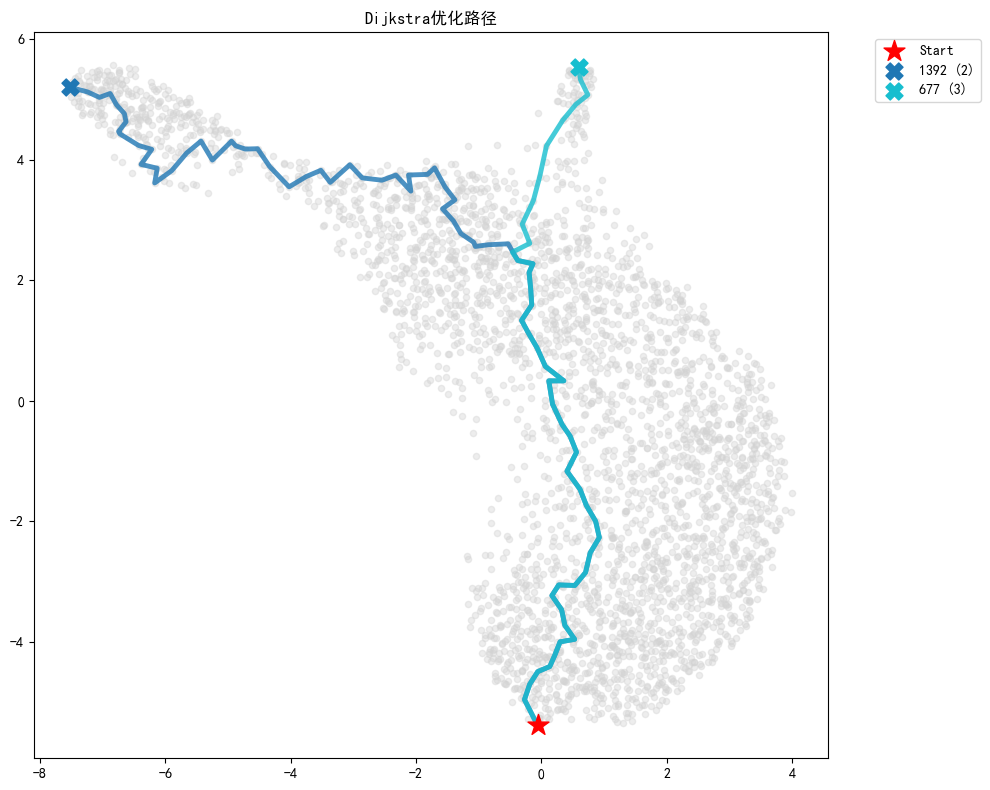

In [26]:
q_learner = QLearningPathFinder(
    adj_matrix=result['knn_adj'],
    coords=umap_coords,
    start_idx=result['start_index'],
    end_indices=result['endpoint_indices'],
    epsilon=0.9,
    alpha=0.1,
    gamma=0.9,
    n_episodes=10000,
    cell_types=cell_types
)

q_learner.train(verbose=True)
sparse_graph = q_learner.build_sparse_graph()
dijkstra_paths = q_learner.find_shortest_paths(sparse_graph)
q_learner.plot_paths(dijkstra_paths, title="Dijkstra优化路径")
# q_learner.evaluate_correlations()

In [21]:
sparse_graph = q_learner.build_sparse_graph()
dijkstra_paths = q_learner.find_shortest_paths(sparse_graph)

In [19]:
import os
import pickle

# 1. 设置文件路径 (使用 r 前缀防止转义字符问题)
file_path = r"D:\Adata\AAA\python——text\Q_result\human_data_5.9.pkl"

# 2. 检查文件是否存在
if os.path.exists(file_path):
    print(f"正在从以下路径恢复数据: \n{file_path}")
    
    try:
        # 3. 使用 pickle 以二进制只读模式 ('rb') 打开
        with open(file_path, 'rb') as f:
            loaded_bundle = pickle.load(f)
        
        # 4. 从字典中还原各个变量
        # 这里的 key 必须与你保存时使用的 key 完全一致
        result = loaded_bundle.get('result')
        results = loaded_bundle.get('results')
        q_learner = loaded_bundle.get('q_learner')
        
        # 如果你之前也保存了 dijkstra_paths，可以一并恢复
        if 'dijkstra_paths' in loaded_bundle:
            dijkstra_paths = loaded_bundle['dijkstra_paths']
            print("✅ 成功恢复：result, results, q_learner, dijkstra_paths")
        else:
            print("✅ 成功恢复：result, results, q_learner")

        # 验证 Q 训练数据
        print(f"📊 Q 表状态数: {len(q_learner.Q)}")
        print(f"📊 分支结果数: {len(results['branch_results'])}")

    except AttributeError:
        print("❌ 错误：当前内存中找不到 QLearningPathFinder 类的定义。")
        print("💡 请先运行定义该类的代码 Cell，然后再执行读取操作。")
    except Exception as e:
        print(f"❌ 读取失败: {e}")

else:
    print(f"❌ 找不到文件，请确认路径是否正确: {file_path}")

正在从以下路径恢复数据: 
D:\Adata\AAA\python——text\Q_result\human_data_5.9.pkl
✅ 成功恢复：result, results, q_learner
📊 Q 表状态数: 3264
📊 分支结果数: 2


--------------------------------------------------
Path Rewards Report
--------------------------------------------------
Target: 1392 (2) | Path Length: 78 steps | Total Reward: 475.07
  Step  0 | Start: 2361 | Reward: 0.00
  Step  1 | Move: 647  | Reward:   +0.96
  Step  2 | Move: 3188 | Reward:   +2.07
  Step  3 | Move: 1462 | Reward:   +2.27
  Step  4 | Move: 1226 | Reward:   +2.28
  Step  5 | Move: 2748 | Reward:   +2.64
  Step  6 | Move: 2858 | Reward:   +2.55
  Step  7 | Move: 1215 | Reward:   +2.23
  Step  8 | Move: 411  | Reward:   +2.41
  Step  9 | Move: 2785 | Reward:   +2.73
  Step 10 | Move: 1439 | Reward:   +2.56
  Step 11 | Move: 1312 | Reward:   +3.25
  Step 12 | Move: 1304 | Reward:   +2.77
  Step 13 | Move: 363  | Reward:   +2.25
  Step 14 | Move: 2747 | Reward:   +2.56
  Step 15 | Move: 3103 | Reward:   +3.05
  Step 16 | Move: 267  | Reward:   +2.97
  Step 17 | Move: 1971 | Reward:   +2.72
  Step 18 | Move: 2410 | Reward:   +2.81
  Step 19 | Move: 2243 | Reward:   +3

C:\Users\Administrator\AppData\Local\Temp\ipykernel_34976\1436068263.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return f"{idx} ({self.cell_types[idx]})"


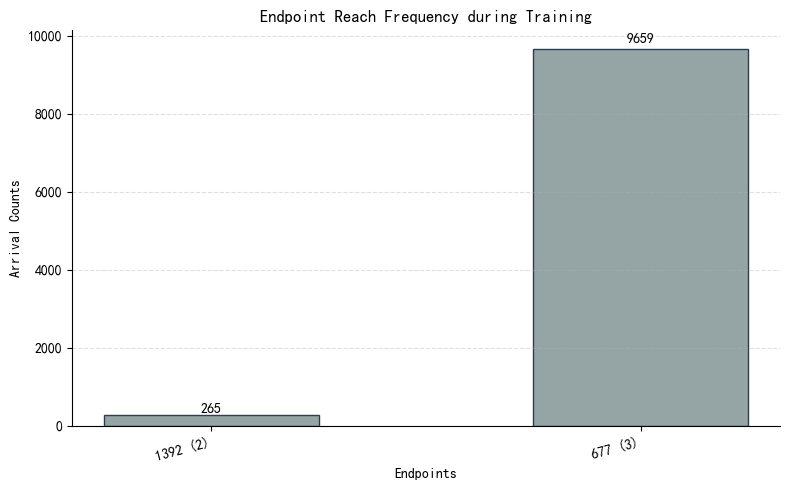

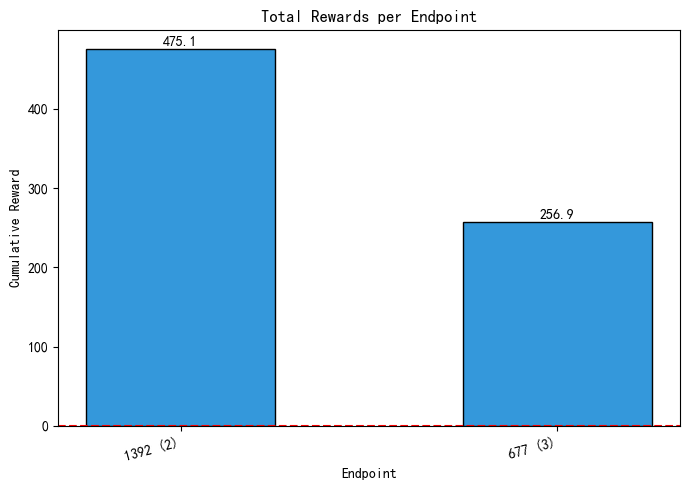

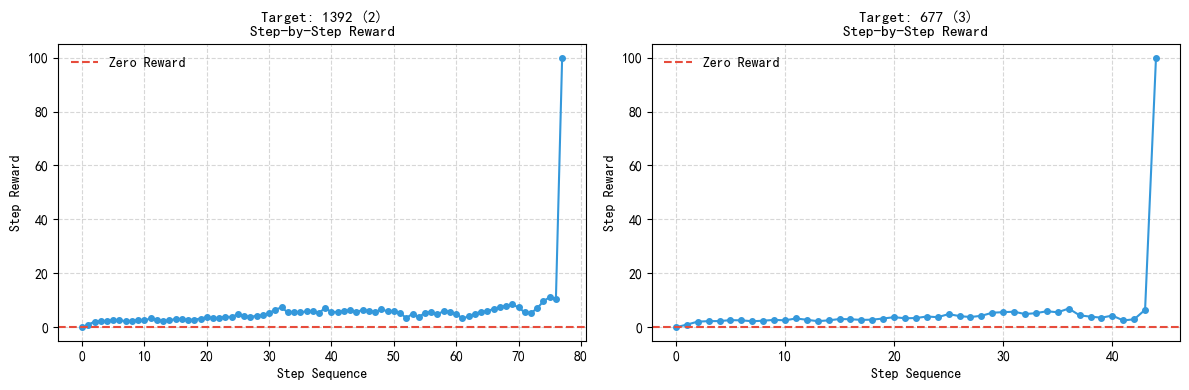

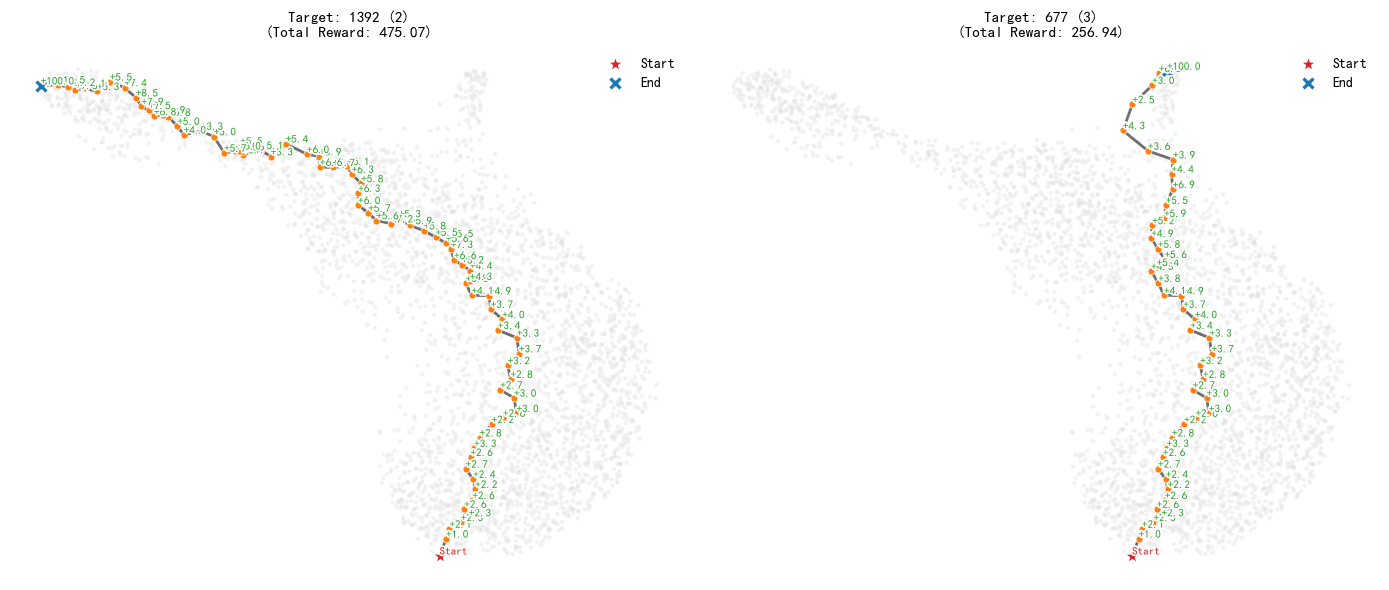

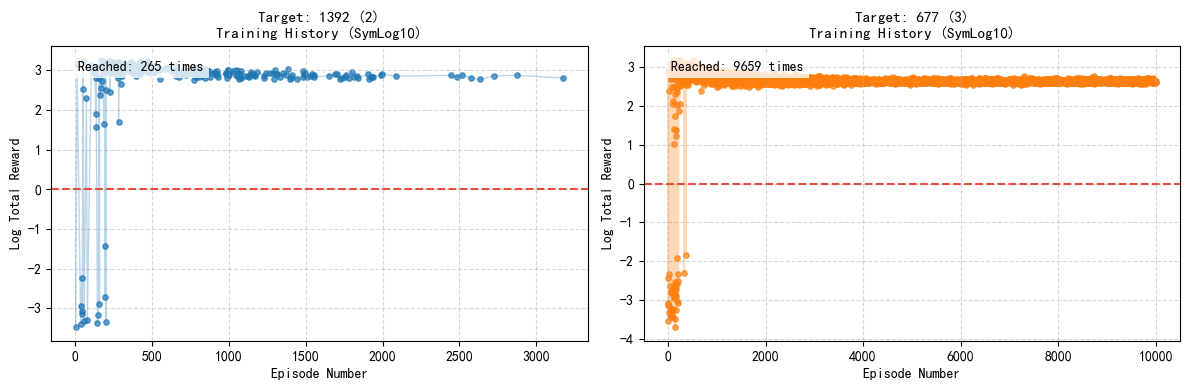

In [28]:
# 2. 打印控制台纯文字详细战报（可选）
q_learner.print_path_rewards_report(dijkstra_paths)

# 3. 连招图 1：展示模型训练曲线 (SymLog10处理)
# q_learner.plot_training_curve()
q_learner.plot_reach_frequency()
# 4. 连招图 2：展示到达各个终点的【总分】与【打转次数】对比图
q_learner.plot_endpoint_statistics(dijkstra_paths)
q_learner.plot_branch_reward_curves(dijkstra_paths)
# 5. 连招图 3：硬核分面图！把每条路径掰开揉碎，每一步得分直接写在图上
q_learner.plot_path_rewards_annotated(dijkstra_paths)
q_learner.plot_endpoint_training_log_rewards()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_34976\3414971098.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return f"{idx} ({self.cell_types[idx]})"


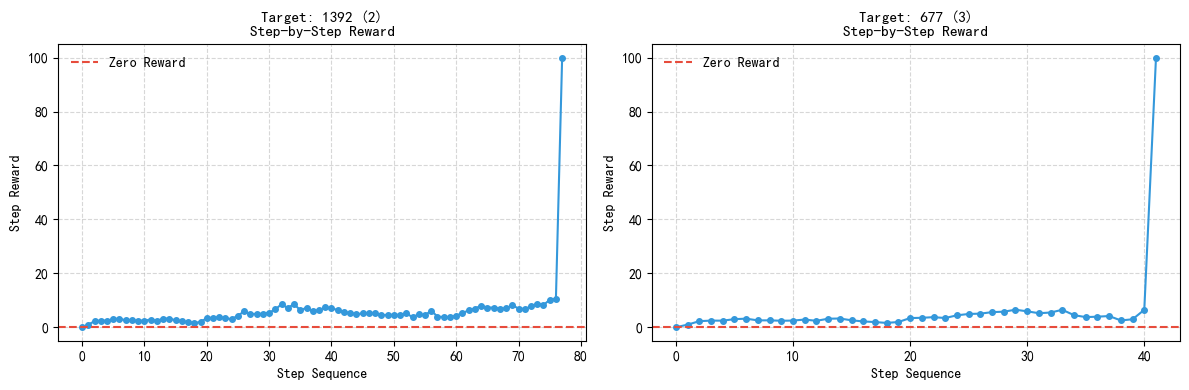

In [14]:
q_learner.plot_branch_reward_curves(dijkstra_paths)

In [96]:
import pandas as pd

# 1. 提取原始的字典格式 Q 表
# (注意：如果你的类里起名叫 self.Q，这里就换成 q_learner.Q)
raw_q_table = q_learner.Q 

# 2. 准备一个空列表，用来装“扁平化”的数据
q_records = []

# 3. 遍历这个稀疏嵌套字典
for source_cell, actions in raw_q_table.items():
    for target_cell, q_value in actions.items():
        # 只提取有意义的连接（排除完全没走过的 0 值记录，压缩体积）
        if q_value != 0:
            q_records.append({
                'Source_Cell': source_cell,
                'Target_Neighbor': target_cell,
                'Q_Value': q_value
            })

# 4. 转换为 Pandas DataFrame
df_q_table = pd.DataFrame(q_records)

# 5. 按 Q 值从大到小排序，看看整个网络里哪条边最“吃香”
df_q_table = df_q_table.sort_values(by='Q_Value', ascending=False).reset_index(drop=True)

# 打印前 10 行看看效果
print(df_q_table.head(10))

# 6. (可选) 保存到本地，方便你随时查阅或用 Gephi/Cytoscape 画图
# df_q_table.to_csv("Extracted_Q_Table.csv", index=False)
print("✅ Q表已成功提取并保存为 CSV！")

   Source_Cell  Target_Neighbor     Q_Value
0         1025             2451  102.009758
1         2451             1733  101.973392
2         1733              254  101.008515
3         1187              481  100.971854
4          481              670  100.736325
5          286             2460  100.619368
6          254              365  100.555509
7          665              481  100.288211
8         1500             1187  100.234108
9         2655             1733  100.171047
✅ Q表已成功提取并保存为 CSV！


In [117]:
import pandas as pd

# 1. 将嵌套字典 (defaultdict) 转换为 Pandas DataFrame
# orient='index' 表示把字典的第一层键（状态/细胞ID）作为行索引，第二层键（动作/目标细胞ID）作为列名
df_q = pd.DataFrame.from_dict(q_matrix, orient='index')

# 可选：如果有些状态没有探索过某些动作，DataFrame 中会出现 NaN，这里可以将其填充为 0
df_q = df_q.fillna(0)

# 2. 导出为 CSV
# ⚠️ 注意：这里我强烈建议把 index=False 改为 index=True！
# 因为你的行索引 (index) 记录的是状态的 ID (也就是细胞 ID)，如果丢掉 index，你打开表格后就不知道哪一行是哪个细胞了。
df_q.to_csv("D:\\Adata\\AAA\\python——text\\Q_result\\Extracted_Q_Table.csv", index=True)

print("✅ Q表已成功导出为 CSV 文件！")

✅ Q表已成功导出为 CSV 文件！


📊 Q-Table Update Report
Total cells: 3264
Updated cells (with incoming Q): 3265
Unupdated cells (isolated): 0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_34976\4044483561.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='Cell_Type', y='State_Value', order=order,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_34976\4044483561.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


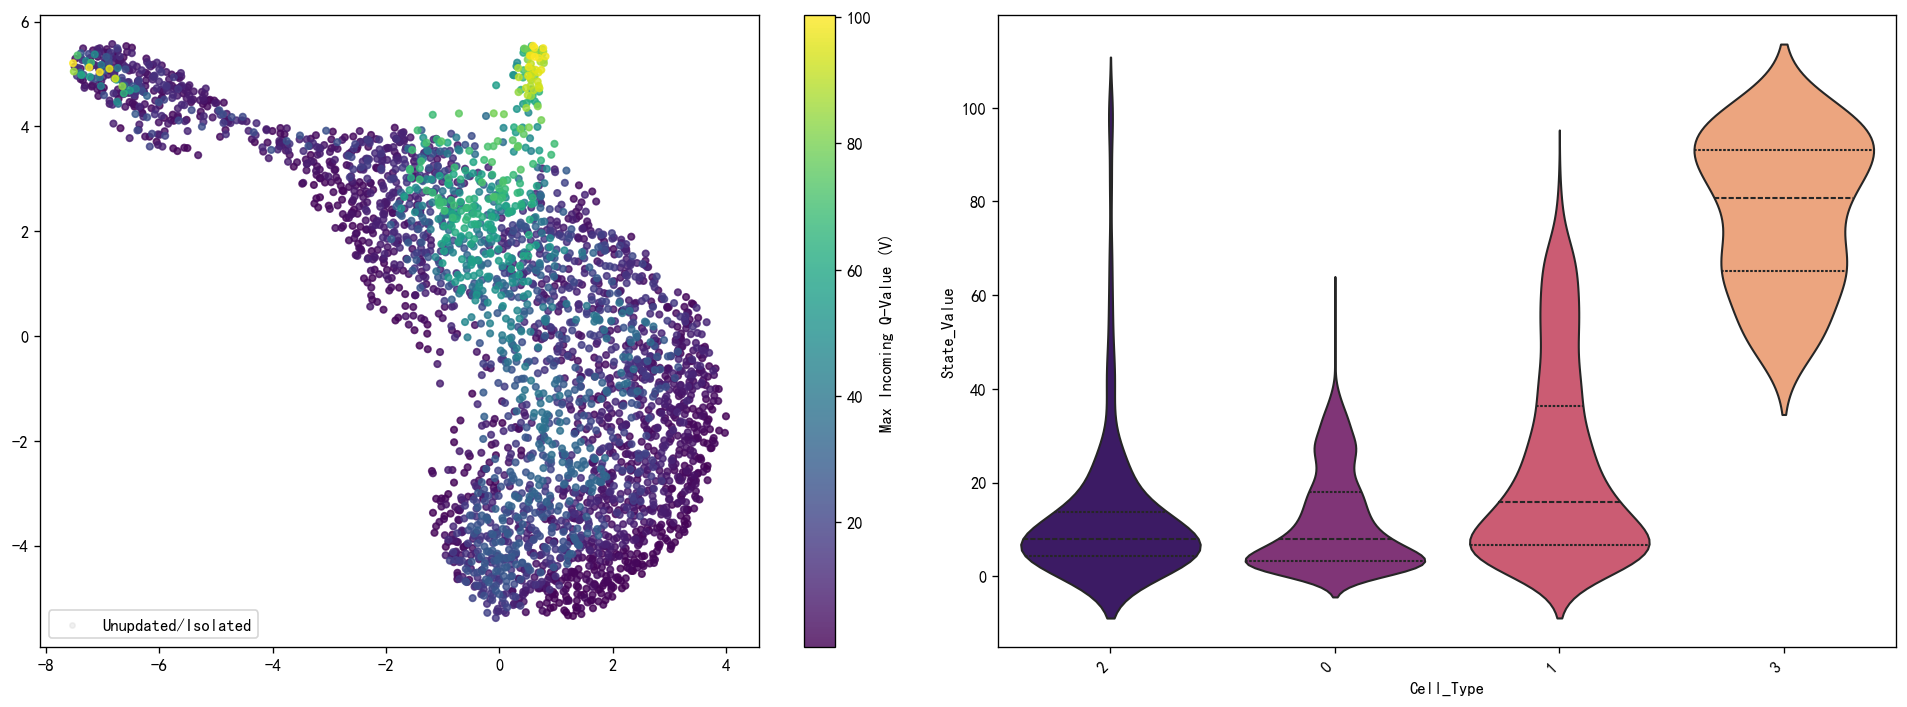

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Extract Max Incoming Q-values
# ==========================================
q_matrix = q_learner.Q
best_incoming_q = {}

# Find the highest incoming Q-value for each target
for source, actions in q_matrix.items():
    for target, q_val in actions.items():
        # Skip unupdated initial actions (q_val == 0)
        if q_val != 0:
            if target not in best_incoming_q or q_val > best_incoming_q[target]:
                best_incoming_q[target] = q_val

# ==========================================
# 2. Map Indices & Detect Unupdated Cells
# ==========================================
# Assuming cell_types.index corresponds to adata.obs_names
all_barcodes = cell_types.index
int_to_barcode = {i: bc for i, bc in enumerate(all_barcodes)}

final_values = {}
unupdated_cells = []

for i, barcode in enumerate(all_barcodes):
    if i in best_incoming_q:
        final_values[barcode] = best_incoming_q[i]
    elif i == q_learner.start:
        # Start node lacks incoming edges; assign baseline later
        final_values[barcode] = None 
    else:
        # Unreached cells (isolated)
        final_values[barcode] = np.nan
        unupdated_cells.append(barcode)

# Fill start node with minimum valid score
valid_scores = [v for v in final_values.values() if v is not None and not np.isnan(v)]
min_score = min(valid_scores) if valid_scores else 0
for bc in final_values:
    if final_values[bc] is None: 
        final_values[bc] = min_score

# ==========================================
# 3. Diagnostic Report
# ==========================================
print("="*40)
print(f"📊 Q-Table Update Report")
print(f"Total cells: {len(all_barcodes)}")
print(f"Updated cells (with incoming Q): {len(best_incoming_q) + 1}")
print(f"Unupdated cells (isolated): {len(unupdated_cells)}")

if unupdated_cells:
    print("\nUnupdated cells ratio by type:")
    missing_stats = cell_types.loc[unupdated_cells].value_counts()
    total_stats = cell_types.value_counts()
    for ctype, count in missing_stats.items():
        print(f" - {ctype}: {count}/{total_stats[ctype]} ({count/total_stats[ctype]*100:.1f}%)")
print("="*40)

# ==========================================
# 4. Plotting
# ==========================================
df_plot = pd.DataFrame({'State_Value': pd.Series(final_values)})
df_plot['Cell_Type'] = cell_types

# Adapt UMAP coordinates
df_plot['UMAP_1'] = umap_coords[:, 0] if isinstance(umap_coords, np.ndarray) else umap_coords.iloc[:, 0].values
df_plot['UMAP_2'] = umap_coords[:, 1] if isinstance(umap_coords, np.ndarray) else umap_coords.iloc[:, 1].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# Plot A: UMAP State Value Heatmap
# Draw unupdated cells with gray background
ax1.scatter(df_plot[df_plot['State_Value'].isna()]['UMAP_1'],
            df_plot[df_plot['State_Value'].isna()]['UMAP_2'],
            c='lightgrey', s=10, alpha=0.3, label='Unupdated/Isolated')

# Sort by value to plot high-value points on top
df_valid = df_plot.dropna(subset=['State_Value']).sort_values('State_Value')
sc = ax1.scatter(df_valid['UMAP_1'], df_valid['UMAP_2'], 
                 c=df_valid['State_Value'], cmap='viridis', s=15, alpha=0.8)

plt.colorbar(sc, ax=ax1, label='Max Incoming Q-Value (V)')
# ax1.set_title("Reinforcement Learning State Value Map", fontsize=14)
ax1.legend(loc='lower left')

# Plot B: Cell Type Violin Plot
df_violin = df_plot.dropna(subset=['State_Value'])
order = df_violin.groupby('Cell_Type')['State_Value'].median().sort_values().index
sns.violinplot(data=df_violin, x='Cell_Type', y='State_Value', order=order, 
               ax=ax2, palette='magma', inner='quartile')
# ax2.set_title("Reward Distribution by Cell Type", fontsize=14)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
import os
import pickle

# ==========================================
# 1. 设定保存路径与文件名
# ==========================================
save_dir = r"D:\Adata\AAA\python——text\Q_result"
file_name = "human_data_6.13.pkl" # 你可以随意修改这个文件名
save_path = os.path.join(save_dir, file_name)

# 确保目标文件夹存在，如果不存在则自动创建
os.makedirs(save_dir, exist_ok=True)

# ==========================================
# 2. 打包核心数据
# ==========================================
# 将你需要的所有核心结果和模型实例打包成一个字典
data_to_save = {
    'result': result,       # 单数：存储 KNN 连通图、邻接矩阵、起点终点索引等
    'results': results,     # 复数：存储各个分支的路径(path)和单轨伪时间等
    'q_learner': q_learner  # Q-learning 模型：内部自带完整的 Q 表和所有的训练历史数据
}

# ==========================================
# 3. 执行持久化保存
# ==========================================
print(f"🔄 正在保存数据到: {save_dir} ...")

try:
    with open(save_path, 'wb') as f:
        pickle.dump(data_to_save, f)
        
    file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
    print(f"✅ 保存成功！\n📂 文件完整路径: {save_path}")
    print(f"📦 文件大小: {file_size_mb:.2f} MB")

except Exception as e:
    print(f"❌ 保存失败，请检查报错信息: {e}")
    print("💡 提示：如果报错 PicklingError，说明由于重复运行单元格导致类定义冲突。请尝试 [Restart Kernel] 后，按顺序执行定义类的代码、训练代码，最后再执行本保存代码。")

🔄 正在保存数据到: D:\Adata\AAA\python——text\Q_result ...
✅ 保存成功！
📂 文件完整路径: D:\Adata\AAA\python——text\Q_result\human_data_5.13.pkl
📦 文件大小: 44.61 MB


In [109]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

def plot_spatial_rewards_with_celltypes(q_learner, paths, coords, cell_types):
    """
    【独立外部函数】
    在 UMAP 降维图上绘制轨迹，节点按细胞类型上色，并标注每一步的奖励值。
    """
    if cell_types is None:
        print("错误：必须提供 cell_types 数组。")
        return
        
    # 1. 从 q_learner 中提取步进奖励数据
    path_totals, path_steps = q_learner.calculate_path_rewards(paths)
    
    n_ends = len(paths)
    cols = min(2, n_ends) # 一行最多放 2 个，保证 UMAP 足够大
    rows = int(np.ceil(n_ends / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(10 * cols, 8 * rows))
    if n_ends == 1: axes = [axes]
    else: axes = axes.flatten()
        
    # 生成全局统一的细胞类型颜色字典
    unique_types = np.unique(cell_types)
    color_palette = plt.cm.tab20(np.linspace(0, 1, len(unique_types)))
    type_to_color = {t: color_palette[i] for i, t in enumerate(unique_types)}
        
    for idx, (end, path) in enumerate(paths.items()):
        ax = axes[idx]
        steps = path_steps[end]
        path_coords = coords[path]
        
        # 🌟 获取当前终点对应的细胞类型
        end_type_name = cell_types[end]
        
        # --- 步骤 A：画 UMAP 全局灰色背景底图 ---
        ax.scatter(coords[:, 0], coords[:, 1], c='#e0e0e0', alpha=0.3, s=15, edgecolors='none')
        
        # --- 步骤 B：画轨迹灰色连线 ---
        ax.plot(path_coords[:, 0], path_coords[:, 1], color='#555555', linewidth=2.5, alpha=0.7, zorder=2)
        
        # --- 步骤 C：画轨迹节点（按细胞类型上色）并标注奖励 ---
        for step_idx, (node_idx, reward) in enumerate(zip(path, steps)):
            c_type = cell_types[node_idx]
            color = type_to_color[c_type]
            
            x, y = coords[node_idx, 0], coords[node_idx, 1]
            
            # 画节点散点 (无需再单独设置 label)
            ax.scatter(x, y, color=color, s=90, edgecolors='white', linewidth=1.2, zorder=5)
            
            # 动态标注奖励数值颜色：<=0 标红，低分标橙，高分标绿
            if step_idx == 0:
                text_label = "Start"
                text_color = "#333333"
            else:
                text_label = f"{reward:+.1f}"
                if reward <= 0: text_color = "#e74c3c"       # 红色：受罚/跨越障碍
                elif reward < 1.5: text_color = "#e67e22"    # 橙色：低分缓慢推进
                else: text_color = "#2ca02c"                 # 绿色：高分加速前进
            
            # 标注数值，添加白色描边防止看不清
            ax.text(x, y + 0.15, text_label, fontsize=10, color=text_color, fontweight='bold', 
                    zorder=10, ha='center', va='bottom',
                    path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
            
        # 🌟 修改标题：增加细胞类型标注
        ax.set_title(f"Target: {end} ({end_type_name})\nSpatial Reward vs Cell Types", fontsize=14, pad=10)
        ax.axis('off')
        
    # 🌟 统一生成图例并放在第一个图 (axes[0]) 的右上角
    # 构建自定义图例元素
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=ctype,
                              markerfacecolor=color, markersize=10)
                       for ctype, color in type_to_color.items()]
    
    # 仅在第一个子图上显示图例，loc='upper right' 代表右上角
    axes[0].legend(handles=legend_elements, loc='upper right', title="Cell Types", 
                   frameon=False, fontsize=11, title_fontsize=12)
        
    # 删掉多余的空白子图
    for i in range(n_ends, len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.show()

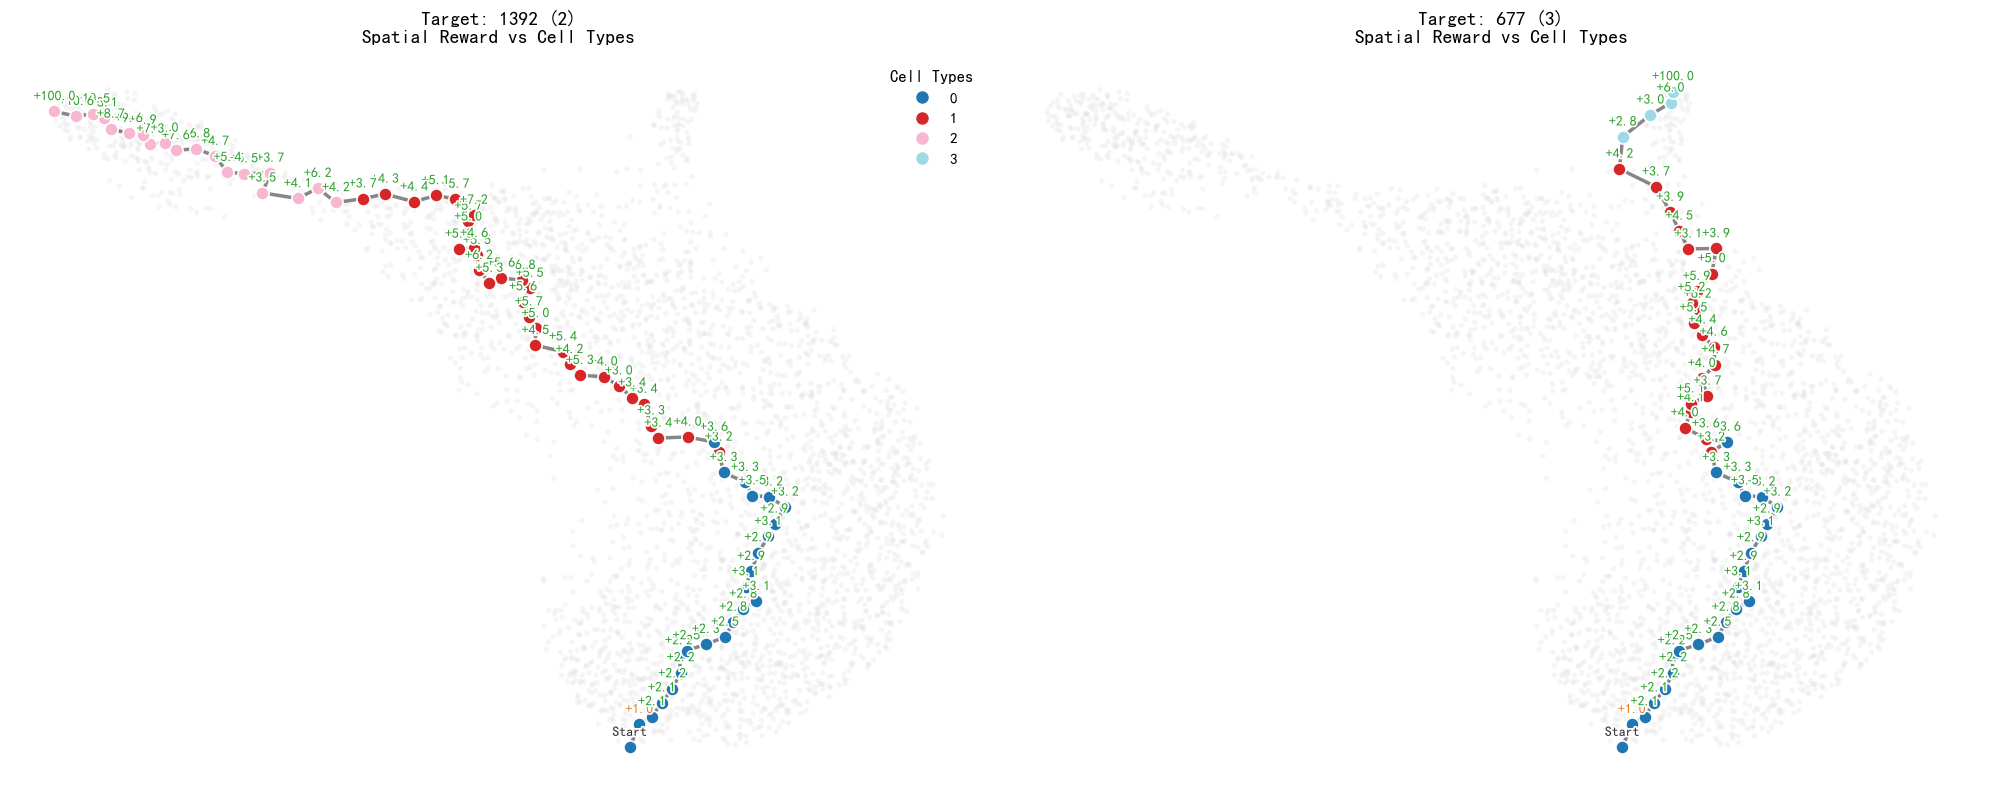

In [110]:
plot_spatial_rewards_with_celltypes(q_learner,dijkstra_paths , umap_coords, cell_types = cell_types)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_34976\1287218123.py:81: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ctype = cell_types[node]


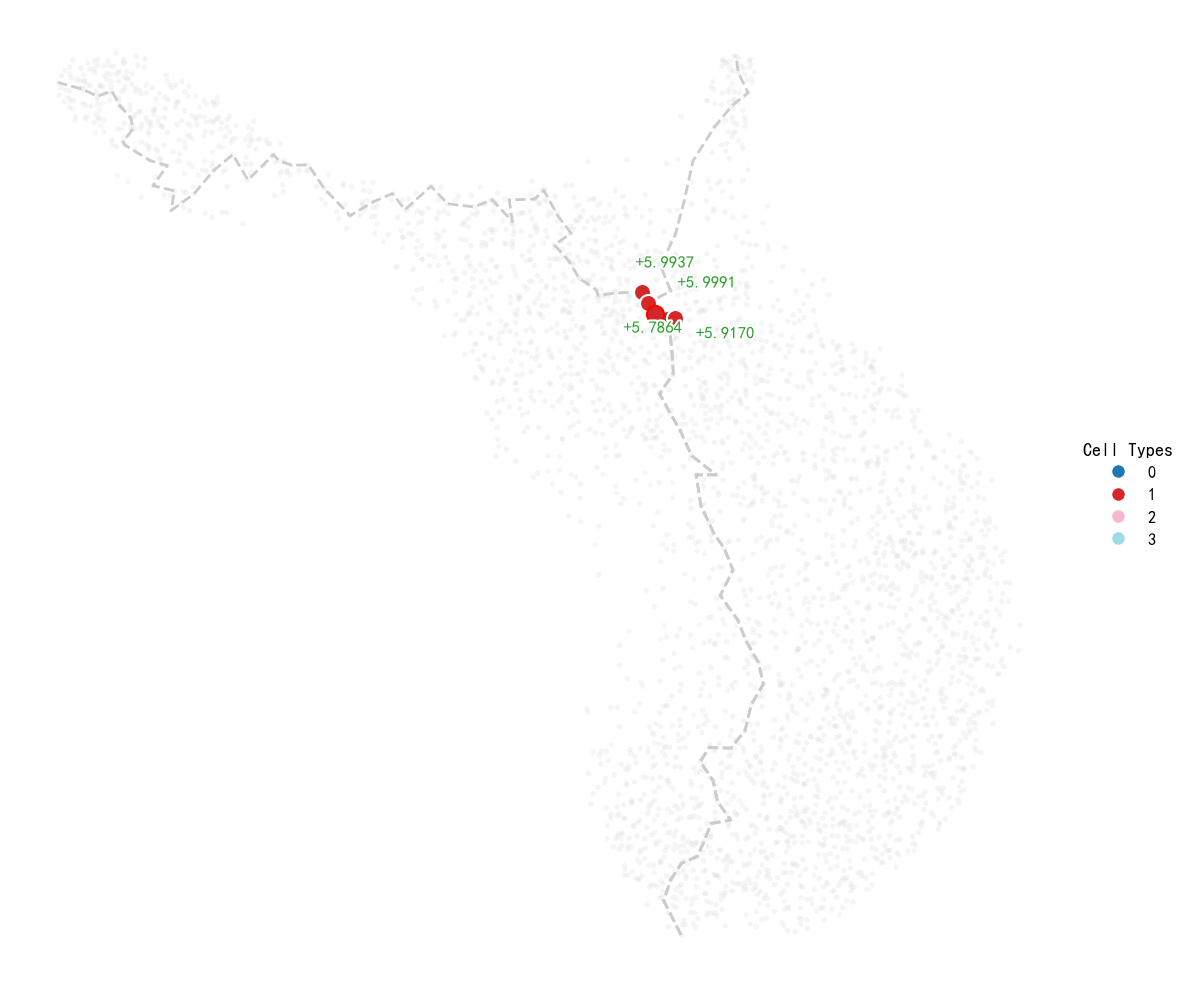

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from adjustText import adjust_text  # 🌟 新增导入，专门解决文字重叠

def plot_branching_points_on_umap(q_learner, paths, coords, cell_types):
    """
    在 UMAP 上可视化分叉点及前后的势能抉择。
    - 分叉点圆圈边框为亮黄色。
    - 统一展示分叉点、前驱节点、后继节点的类型颜色、类型名称及步进奖励。
    - 🌟 使用 adjustText 自动避免文本标签覆盖。
    """
    if cell_types is None:
        print("错误：必须提供 cell_types 数组。")
        return
        
    # 1. 提取步进奖励数据并寻找分叉点
    path_totals, path_steps = q_learner.calculate_path_rewards(paths)
    
    out_edges = {}
    for end_node, path in paths.items():
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            if u not in out_edges: out_edges[u] = set()
            out_edges[u].add(v)
            
    branching_points = [u for u, targets in out_edges.items() if len(targets) > 1]
    
    if not branching_points:
        print("未检测到多分支的分叉点！")
        return
        
    # 2. 准备绘图与颜色字典
    fig, ax = plt.subplots(figsize=(12, 10))
    unique_types = np.unique(cell_types)
    color_palette = plt.cm.tab20(np.linspace(0, 1, len(unique_types)))
    type_to_color = {t: color_palette[i] for i, t in enumerate(unique_types)}
    
    # 3. 画 UMAP 灰色底点和所有轨迹的虚线底纹
    ax.scatter(coords[:, 0], coords[:, 1], c='#e0e0e0', alpha=0.3, s=15, edgecolors='none')
    for end_node, path in paths.items():
        path_coords = coords[path]
        ax.plot(path_coords[:, 0], path_coords[:, 1], color='#cccccc', linewidth=2, linestyle='--', zorder=1)
        
    # 4. 收集需要绘制的重点节点和连线
    nodes_to_draw = {}  
    edges_to_draw = set() 
    
    for bp in branching_points:
        for end_node, path in paths.items():
            if bp in path:
                idx = path.index(bp)
                nodes_to_draw[bp] = path_steps[end_node][idx]
                if idx > 0:
                    prev = path[idx - 1]
                    nodes_to_draw[prev] = path_steps[end_node][idx - 1]
                    edges_to_draw.add((prev, bp))
                break
                
        for v in out_edges[bp]:
            for end_node, path in paths.items():
                if bp in path and v in path:
                    nodes_to_draw[v] = path_steps[end_node][path.index(v)]
                    edges_to_draw.add((bp, v))
                    break

    # 5. 渲染连线箭头
    for u, v in edges_to_draw:
        ax.annotate("", xy=coords[v], xytext=coords[u],
                    arrowprops=dict(arrowstyle="-|>", color='#555555', lw=2.5, mutation_scale=15), zorder=5)

    # 🌟 准备一个列表，用于收集所有的文字对象
    texts = []
    
    # 记录需要避开的点坐标 (让文字不要挡住圆点)
    point_xs, point_ys = [], []

    # 6. 渲染重点节点
    for node, reward in nodes_to_draw.items():
        ctype = cell_types[node]
        color = type_to_color[ctype]
        x, y = coords[node, 0], coords[node, 1]
        
        point_xs.append(x)
        point_ys.append(y)
        
        if node in branching_points:
            ax.scatter(x, y, color=color, s=150, edgecolors="#FF0000", linewidth=1.5, zorder=9)
        else:
            ax.scatter(x, y, color=color, s=150, edgecolors='white', linewidth=1.5, zorder=8)
            
        # 标注奖励数值
        text_color = "#e74c3c" if reward <= 0 else ("#e67e22" if reward < 1.5 else "#2ca02c")
        
        # 🌟 注意这里：不再强制设置 y-0.18 和 ha/va，而是把生成的 text 对象存进 texts 列表
        t = ax.text(x, y, f"{reward:+.4f}", fontsize=12, color=text_color, fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")], zorder=15)
        texts.append(t)

    # 🌟 7. 魔法发生的地方：调用 adjustText 自动排版
    if texts:
        adjust_text(texts, 
                    x=point_xs, y=point_ys,           # 让文字自动避开这些圆点
                    force_text=(0.5, 0.8),            # 文字之间的斥力
                    force_points=(1.0, 1.0),          # 文字与点之间的斥力
                    expand_points=(1.5, 1.5),         # 把点的影响范围稍微放大
                    # arrowprops=dict(arrowstyle='-', color='#999999', lw=1.5, alpha=0.7, zorder=10)
                     ) # 如果文字被挤远了，自动画一根灰线指向原点

    # 8. 美化与图例
    # ax.set_title("Trajectory Branching Points Visualization", fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')
    
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=ctype,
                              markerfacecolor=color, markersize=10)
                       for ctype, color in type_to_color.items()]
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.0, 0.5), 
              title="Cell Types", frameon=False, fontsize=12, title_fontsize=13)
    
    plt.tight_layout()
    plt.show()
plot_branching_points_on_umap(
    q_learner=q_learner, 
    paths=dijkstra_paths, 
    coords=umap_coords[:,[0,1]], 
    cell_types=cell_types
)

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from scipy.sparse.csgraph import dijkstra
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


def compute_branch_pseudotimes(dijkstra_paths, n_cells):
    """Compute branch pseudotime (0-1 scale)."""
    branch_results = {}
    print(f"Computing pseudotime for {len(dijkstra_paths)} branches...")
    
    for i, (endpoint, path) in enumerate(dijkstra_paths.items()):
        if len(path) < 2:
            continue
            
        branch_pt = np.full(n_cells, -1.0, dtype=np.float32)
        for idx, cell in enumerate(path):
            branch_pt[cell] = idx / (len(path) - 1)
        
        branch_mask = branch_pt >= 0
        
        branch_results[i] = {
            'pseudotime': branch_pt,
            'mask': branch_mask,
            'path': path,
            'length': len(path),
            'endpoint_cell': path[-1],
            'original_endpoint': endpoint
        }
    
    return branch_results


def compute_graph_distance_global_pseudotime(dijkstra_paths, umap_coords, n_cells, knn_graph):
    """Compute global pseudotime using graph distance ratios."""
    if not dijkstra_paths:
        return None, None, None

    # 1. Find start node
    all_paths = list(dijkstra_paths.values())
    start_cells = set(all_paths[0])
    for path in all_paths[1:]:
        start_cells.intersection_update(set(path))
    start_cell = min(start_cells) if start_cells else (all_paths[0][0] if all_paths[0] else 0)
    
    # 2. Get distances for endpoints
    endpoints = list(dijkstra_paths.keys())
    endpoint_distances = {}
    for endpoint in endpoints:
        try:
            distance = nx.shortest_path_length(knn_graph, start_cell, endpoint, weight='weight')
            if distance < np.inf:
                endpoint_distances[endpoint] = distance
            else:
                for path in all_paths:
                    if path[-1] == endpoint:
                        endpoint_distances[endpoint] = len(path)
                        break
        except:
            for path in all_paths:
                if path[-1] == endpoint:
                    endpoint_distances[endpoint] = len(path)
                    break
    
    if not endpoint_distances:
        return None, None, None
    
    max_distance = max(endpoint_distances.values())
    
    # 3. Calculate target ratios
    endpoint_ratios = {}
    for endpoint, dist in endpoint_distances.items():
        endpoint_ratios[endpoint] = dist / max_distance if max_distance > 0 else 1.0
    
    # 4. Assign pseudotime
    global_pt = np.full(n_cells, -1.0, dtype=np.float32)
    for endpoint, path in dijkstra_paths.items():
        if len(path) < 2: continue
        target_ratio = endpoint_ratios.get(endpoint, 1.0)
        
        for cell in path:
            if cell == start_cell:
                global_pt[cell] = 0.0
            elif cell == endpoint:
                global_pt[cell] = target_ratio
            else:
                if cell in path:
                    cell_idx = path.index(cell)
                    cell_ratio = (cell_idx / (len(path) - 1)) * target_ratio
                    if global_pt[cell] >= 0:
                        global_pt[cell] = (global_pt[cell] + cell_ratio) / 2
                    else:
                        global_pt[cell] = cell_ratio

    # 5. Resolve bifurcation overlaps
    cell_path_count = {}
    for path in dijkstra_paths.values():
        for cell in path:
            cell_path_count[cell] = cell_path_count.get(cell, 0) + 1
            
    for cell, count in cell_path_count.items():
        if count > 1 and global_pt[cell] >= 0:
            values = []
            for endpoint, path in dijkstra_paths.items():
                if cell in path:
                    cell_idx = path.index(cell)
                    target_ratio = endpoint_ratios.get(endpoint, 1.0)
                    values.append((cell_idx / (len(path) - 1)) * target_ratio)
            if values:
                global_pt[cell] = np.mean(values)

    # Apply limits
    valid_mask = global_pt >= 0
    if valid_mask.any():
        global_pt[valid_mask] = np.clip(global_pt[valid_mask], 0.0, 1.0)
    
    global_pt[start_cell] = 0.0
    for endpoint, ratio in endpoint_ratios.items():
        if endpoint < n_cells:
            global_pt[endpoint] = ratio

    return global_pt, valid_mask, start_cell


def compute_enhanced_rf_pseudotime_with_global(global_pt, umap_coords):
    """Train RF model using global pseudotime."""
    n_cells = len(umap_coords)
    print("Training RF model with global pseudotime...")
    
    if global_pt is None:
        return None, None
    
    train_mask = global_pt >= 0
    if train_mask.sum() < 20:
        return global_pt, train_mask
    
    X_train = umap_coords[train_mask]
    y_train = global_pt[train_mask]
    
    try:
        rf_model = RandomForestRegressor(
            n_estimators=200, max_depth=20, min_samples_split=5,
            min_samples_leaf=1, random_state=42, n_jobs=-1
        )
        rf_model.fit(X_train, y_train)
        
        rf_pt = rf_model.predict(umap_coords)
        rf_pt = np.clip(rf_pt, 0.0, 1.0001)
        
        min_pt_idx = np.argmin(global_pt[train_mask])
        start_cell = np.where(train_mask)[0][min_pt_idx]
        rf_pt[start_cell] = 0.0
        
        print(f"RF pseudotime range: [{rf_pt.min():.3f}, {rf_pt.max():.3f}]")
        return rf_pt, np.ones(n_cells, dtype=bool)
        
    except Exception as e:
        print(f"RF training failed: {e}")
        return global_pt, train_mask


def evaluate_pseudotime(pseudotime, true_labels, cell_types, mask):
    """Evaluate pseudotime accuracy."""
    # Filter valid depth map cells
    valid_mask = mask & (true_labels != -1)
    
    pt_traj = pseudotime[valid_mask]
    y_traj = true_labels[valid_mask]
    cell_types_traj = cell_types[valid_mask]
    
    if len(pt_traj) < 2 or len(np.unique(cell_types_traj)) < 2:
        return [np.nan] * 4
        
    try:
        # Proportional binning
        props = pd.Series(cell_types_traj).value_counts(normalize=True).sort_index()
        bins = [0.0] + props.cumsum().tolist()
        bins[-1] = 1.0001
        
        bins = np.unique(np.sort(bins))
        pred_bins = pd.cut(pt_traj, bins=bins, right=False, duplicates='drop')
        unique_pred = np.unique(pred_bins)
        label_map = {l: i for i, l in enumerate(unique_pred)}
        pred_encoded = np.array([label_map.get(l, -1) for l in pred_bins])
        valid = pred_encoded != -1
        
        if valid.sum() < 2:
            return [np.nan] * 4
            
        ari = adjusted_rand_score(y_traj[valid], pred_encoded[valid])
        nmi = normalized_mutual_info_score(y_traj[valid], pred_encoded[valid])
        
        # Calculate correlations
        pcc = abs(pearsonr(pt_traj, y_traj)[0])
        spr = abs(spearmanr(pt_traj, y_traj)[0])
        
        return [ari, nmi, pcc, spr]
    except Exception as e:
        print(f"Evaluation failed: {e}")
        return [np.nan] * 4


def evaluate_all_branches(branch_results, true_labels, cell_types):
    """Evaluate all branch pseudotimes."""
    branch_metrics = {}
    print("\nEvaluating branch pseudotimes:")
    
    for branch_id, branch_data in branch_results.items():
        metrics = evaluate_pseudotime(
            branch_data['pseudotime'],
            true_labels,
            cell_types,
            branch_data['mask']
        )
        
        branch_metrics[branch_id] = {
            'metrics': metrics,
            'length': branch_data['length'],
            'endpoint': branch_data['original_endpoint']
        }
        
        print(f"  Branch {branch_id+1} (Length {branch_data['length']}, End {branch_data['original_endpoint']}):")
        print(f"    ARI={metrics[0]:.4f}, NMI={metrics[1]:.4f}, PCC={metrics[2]:.4f}, Spearman={metrics[3]:.4f}")
    
    if branch_metrics:
        all_metrics = np.array([data['metrics'] for data in branch_metrics.values()])
        avg_metrics = np.nanmean(all_metrics, axis=0)
        print(f"\nAverage Branch Metrics:")
        print(f"  ARI={avg_metrics[0]:.4f}, NMI={avg_metrics[1]:.4f}, PCC={avg_metrics[2]:.4f}, Spearman={avg_metrics[3]:.4f}")
    else:
        avg_metrics = np.array([np.nan]*4)
        
    return branch_metrics, avg_metrics


def main_final_analysis_enhanced(q_learner, umap_coords, cell_types, knn_graph):
    """Main pipeline for enhanced pseudotime analysis."""
    print("=" * 70)
    print("Enhanced Pseudotime Analysis")
    print("=" * 70)
    
    # 1. Fetch trajectories
    print("\n1. Fetching RL trajectories...")
    sparse_graph = q_learner.build_sparse_graph()
    dijkstra_paths = q_learner.find_shortest_paths(sparse_graph)
    
    print(f"Found {len(dijkstra_paths)} paths:")
    for i, (endpoint, path) in enumerate(dijkstra_paths.items()):
        print(f"  Path {i+1}: End {endpoint}, Length={len(path)}")
    
    # 2. Branch pseudotime
    n_cells = len(umap_coords)
    branch_results = compute_branch_pseudotimes(dijkstra_paths, n_cells)
    
    # 3. Global pseudotime
    print("\n3. Computing global pseudotime...")
    global_pt, global_mask, start_cell = compute_graph_distance_global_pseudotime(
        dijkstra_paths, umap_coords, n_cells, knn_graph
    )
    
    # 4. RF pseudotime
    print("\n4. Computing enhanced RF pseudotime...")
    rf_pt, rf_mask = compute_enhanced_rf_pseudotime_with_global(global_pt, umap_coords)
    
    # 5. Evaluate
    print("\n5. Evaluating pseudotime...")
    
    depth_map = {"0": 0, "1": 1, "2": 2, "3": 2}
    true_labels = np.array([depth_map.get(str(t), -1) for t in cell_types])
    
    missing_cells = (true_labels == -1).sum()
    if missing_cells > 0:
        print(f"Warning: {missing_cells} cells not in depth_map, ignoring in evaluation.")
    
    branch_metrics, avg_branch_metrics = evaluate_all_branches(
        branch_results, true_labels, cell_types
    )
    
    global_metrics = None
    if global_pt is not None and global_mask is not None:
        global_metrics = evaluate_pseudotime(global_pt, true_labels, cell_types, global_mask)
        print(f"\nGlobal Pseudotime Metrics:")
        print(f"  ARI={global_metrics[0]:.4f}, NMI={global_metrics[1]:.4f}")
        print(f"  PCC={global_metrics[2]:.4f}, Spearman={global_metrics[3]:.4f}")
    
    rf_metrics = None
    if rf_pt is not None:
        rf_metrics = evaluate_pseudotime(rf_pt, true_labels, cell_types, rf_mask)
        print(f"\nRF Pseudotime Metrics:")
        print(f"  ARI={rf_metrics[0]:.4f}, NMI={rf_metrics[1]:.4f}")
        print(f"  PCC={rf_metrics[2]:.4f}, Spearman={rf_metrics[3]:.4f}")
    
    # 7. Summary
    print("\n" + "=" * 70)
    print("Analysis Summary")
    print("=" * 70)
    
    comparison_data = []
    
    for branch_id, data in branch_metrics.items():
        comparison_data.append({
            'Method': f'Branch {branch_id+1} PT',
            'Type': 'Branch PT',
            'ARI': f"{data['metrics'][0]:.4f}",
            'NMI': f"{data['metrics'][1]:.4f}",
            'Pearson': f"{data['metrics'][2]:.4f}",
            'Spearman': f"{data['metrics'][3]:.4f}",
            'Length': data['length'],
            'Endpoint': data['endpoint']
        })
    
    comparison_data.append({
        'Method': 'Avg Branch PT',
        'Type': 'Branch PT',
        'ARI': f"{avg_branch_metrics[0]:.4f}",
        'NMI': f"{avg_branch_metrics[1]:.4f}",
        'Pearson': f"{avg_branch_metrics[2]:.4f}",
        'Spearman': f"{avg_branch_metrics[3]:.4f}",
        'Length': '-',
        'Endpoint': '-'
    })
    
    if global_metrics is not None:
        comparison_data.append({
            'Method': 'Global PT',
            'Type': 'Global PT',
            'ARI': f"{global_metrics[0]:.4f}",
            'NMI': f"{global_metrics[1]:.4f}",
            'Pearson': f"{global_metrics[2]:.4f}",
            'Spearman': f"{global_metrics[3]:.4f}",
            'Length': '-',
            'Endpoint': f'Start:{start_cell}'
        })
    
    if rf_metrics is not None:
        comparison_data.append({
            'Method': 'Enhanced RF PT',
            'Type': 'Global PT',
            'ARI': f"{rf_metrics[0]:.4f}",
            'NMI': f"{rf_metrics[1]:.4f}",
            'Pearson': f"{rf_metrics[2]:.4f}",
            'Spearman': f"{rf_metrics[3]:.4f}",
            'Length': '-',
            'Endpoint': '-'
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    print("\nEvaluation Comparison:")
    print(df_comparison.to_string(index=False))
    
    if len(comparison_data) > 0:
        print(f"\nRecommended Method:")
        df_temp = pd.DataFrame(comparison_data)
        numeric_cols = ['ARI', 'NMI', 'Pearson', 'Spearman']
        
        for col in numeric_cols:
            df_temp[col] = df_temp[col].astype(float)
            
        df_temp['Score'] = df_temp[numeric_cols].mean(axis=1)
        best_idx = df_temp['Score'].idxmax()
        best_method = df_temp.loc[best_idx]
        
        print(f"  {best_method['Method']} (Score: {best_method['Score']:.4f})")
        print(f"    ARI={best_method['ARI']:.4f}, NMI={best_method['NMI']:.4f}")
        print(f"    Pearson={best_method['Pearson']:.4f}, Spearman={best_method['Spearman']:.4f}")
    
    return {
        'branch_results': branch_results,
        'branch_metrics': branch_metrics,
        'avg_branch_metrics': avg_branch_metrics,
        'global_pseudotime': global_pt,
        'global_metrics': global_metrics,
        'rf_pseudotime': rf_pt,
        'rf_metrics': rf_metrics,
        'start_cell': start_cell,
        'comparison_df': df_comparison
    }

# Execute main pipeline
results = main_final_analysis_enhanced(q_learner, umap_coords, adata.obs['cluster'].values, result['knn_graph'])
# adata.obs['QLearning_pseudotime'] = results['rf_pseudotime']

Enhanced Pseudotime Analysis

1. Fetching RL trajectories...
Found 2 paths:
  Path 1: End 1392, Length=79
  Path 2: End 677, Length=46
Computing pseudotime for 2 branches...

3. Computing global pseudotime...

4. Computing enhanced RF pseudotime...
Training RF model with global pseudotime...
RF pseudotime range: [0.000, 0.973]

5. Evaluating pseudotime...

Evaluating branch pseudotimes:
  Branch 1 (Length 79, End 1392):
    ARI=0.9190, NMI=0.8981, PCC=0.9338, Spearman=0.9339
  Branch 2 (Length 46, End 677):
    ARI=1.0000, NMI=1.0000, PCC=0.8967, Spearman=0.9065

Average Branch Metrics:
  ARI=0.9595, NMI=0.9491, PCC=0.9153, Spearman=0.9202

Global Pseudotime Metrics:
  ARI=0.6483, NMI=0.6412
  PCC=0.8784, Spearman=0.8726

RF Pseudotime Metrics:
  ARI=0.2925, NMI=0.3758
  PCC=0.8724, Spearman=0.8511

Analysis Summary

Evaluation Comparison:
        Method      Type    ARI    NMI Pearson Spearman Length Endpoint
   Branch 1 PT Branch PT 0.9190 0.8981  0.9338   0.9339     79     1392
   B

In [ ]:
import os
import pickle

# 1. 设置文件路径 (使用 r 前缀防止转义字符问题)
file_path = r"D:\Adata\AAA\python——text\Q_result\human_data_5.13.pkl"

# 2. 检查文件是否存在
if os.path.exists(file_path):
    print(f"正在从以下路径恢复数据: \n{file_path}")
    
    try:
        # 3. 使用 pickle 以二进制只读模式 ('rb') 打开
        with open(file_path, 'rb') as f:
            loaded_bundle = pickle.load(f)
        
        # 4. 从字典中还原各个变量
        # 这里的 key 必须与你保存时使用的 key 完全一致
        result = loaded_bundle.get('result')
        results = loaded_bundle.get('results')
        q_learner = loaded_bundle.get('q_learner')
        
        # 如果你之前也保存了 dijkstra_paths，可以一并恢复
        if 'dijkstra_paths' in loaded_bundle:
            dijkstra_paths = loaded_bundle['dijkstra_paths']
            print("✅ 成功恢复：result, results, q_learner, dijkstra_paths")
        else:
            print("✅ 成功恢复：result, results, q_learner")

        # 验证 Q 训练数据
        print(f"📊 Q 表状态数: {len(q_learner.Q)}")
        print(f"📊 分支结果数: {len(results['branch_results'])}")

    except AttributeError:
        print("❌ 错误：当前内存中找不到 QLearningPathFinder 类的定义。")
        print("💡 请先运行定义该类的代码 Cell，然后再执行读取操作。")
    except Exception as e:
        print(f"❌ 读取失败: {e}")

else:
    print(f"❌ 找不到文件，请确认路径是否正确: {file_path}")

正在从以下路径恢复数据: 
D:\Adata\AAA\python——text\compare\pkl_data\human_data.pkl
✅ 成功恢复：result, results, q_learner
📊 Q 表状态数: 3264
📊 分支结果数: 2


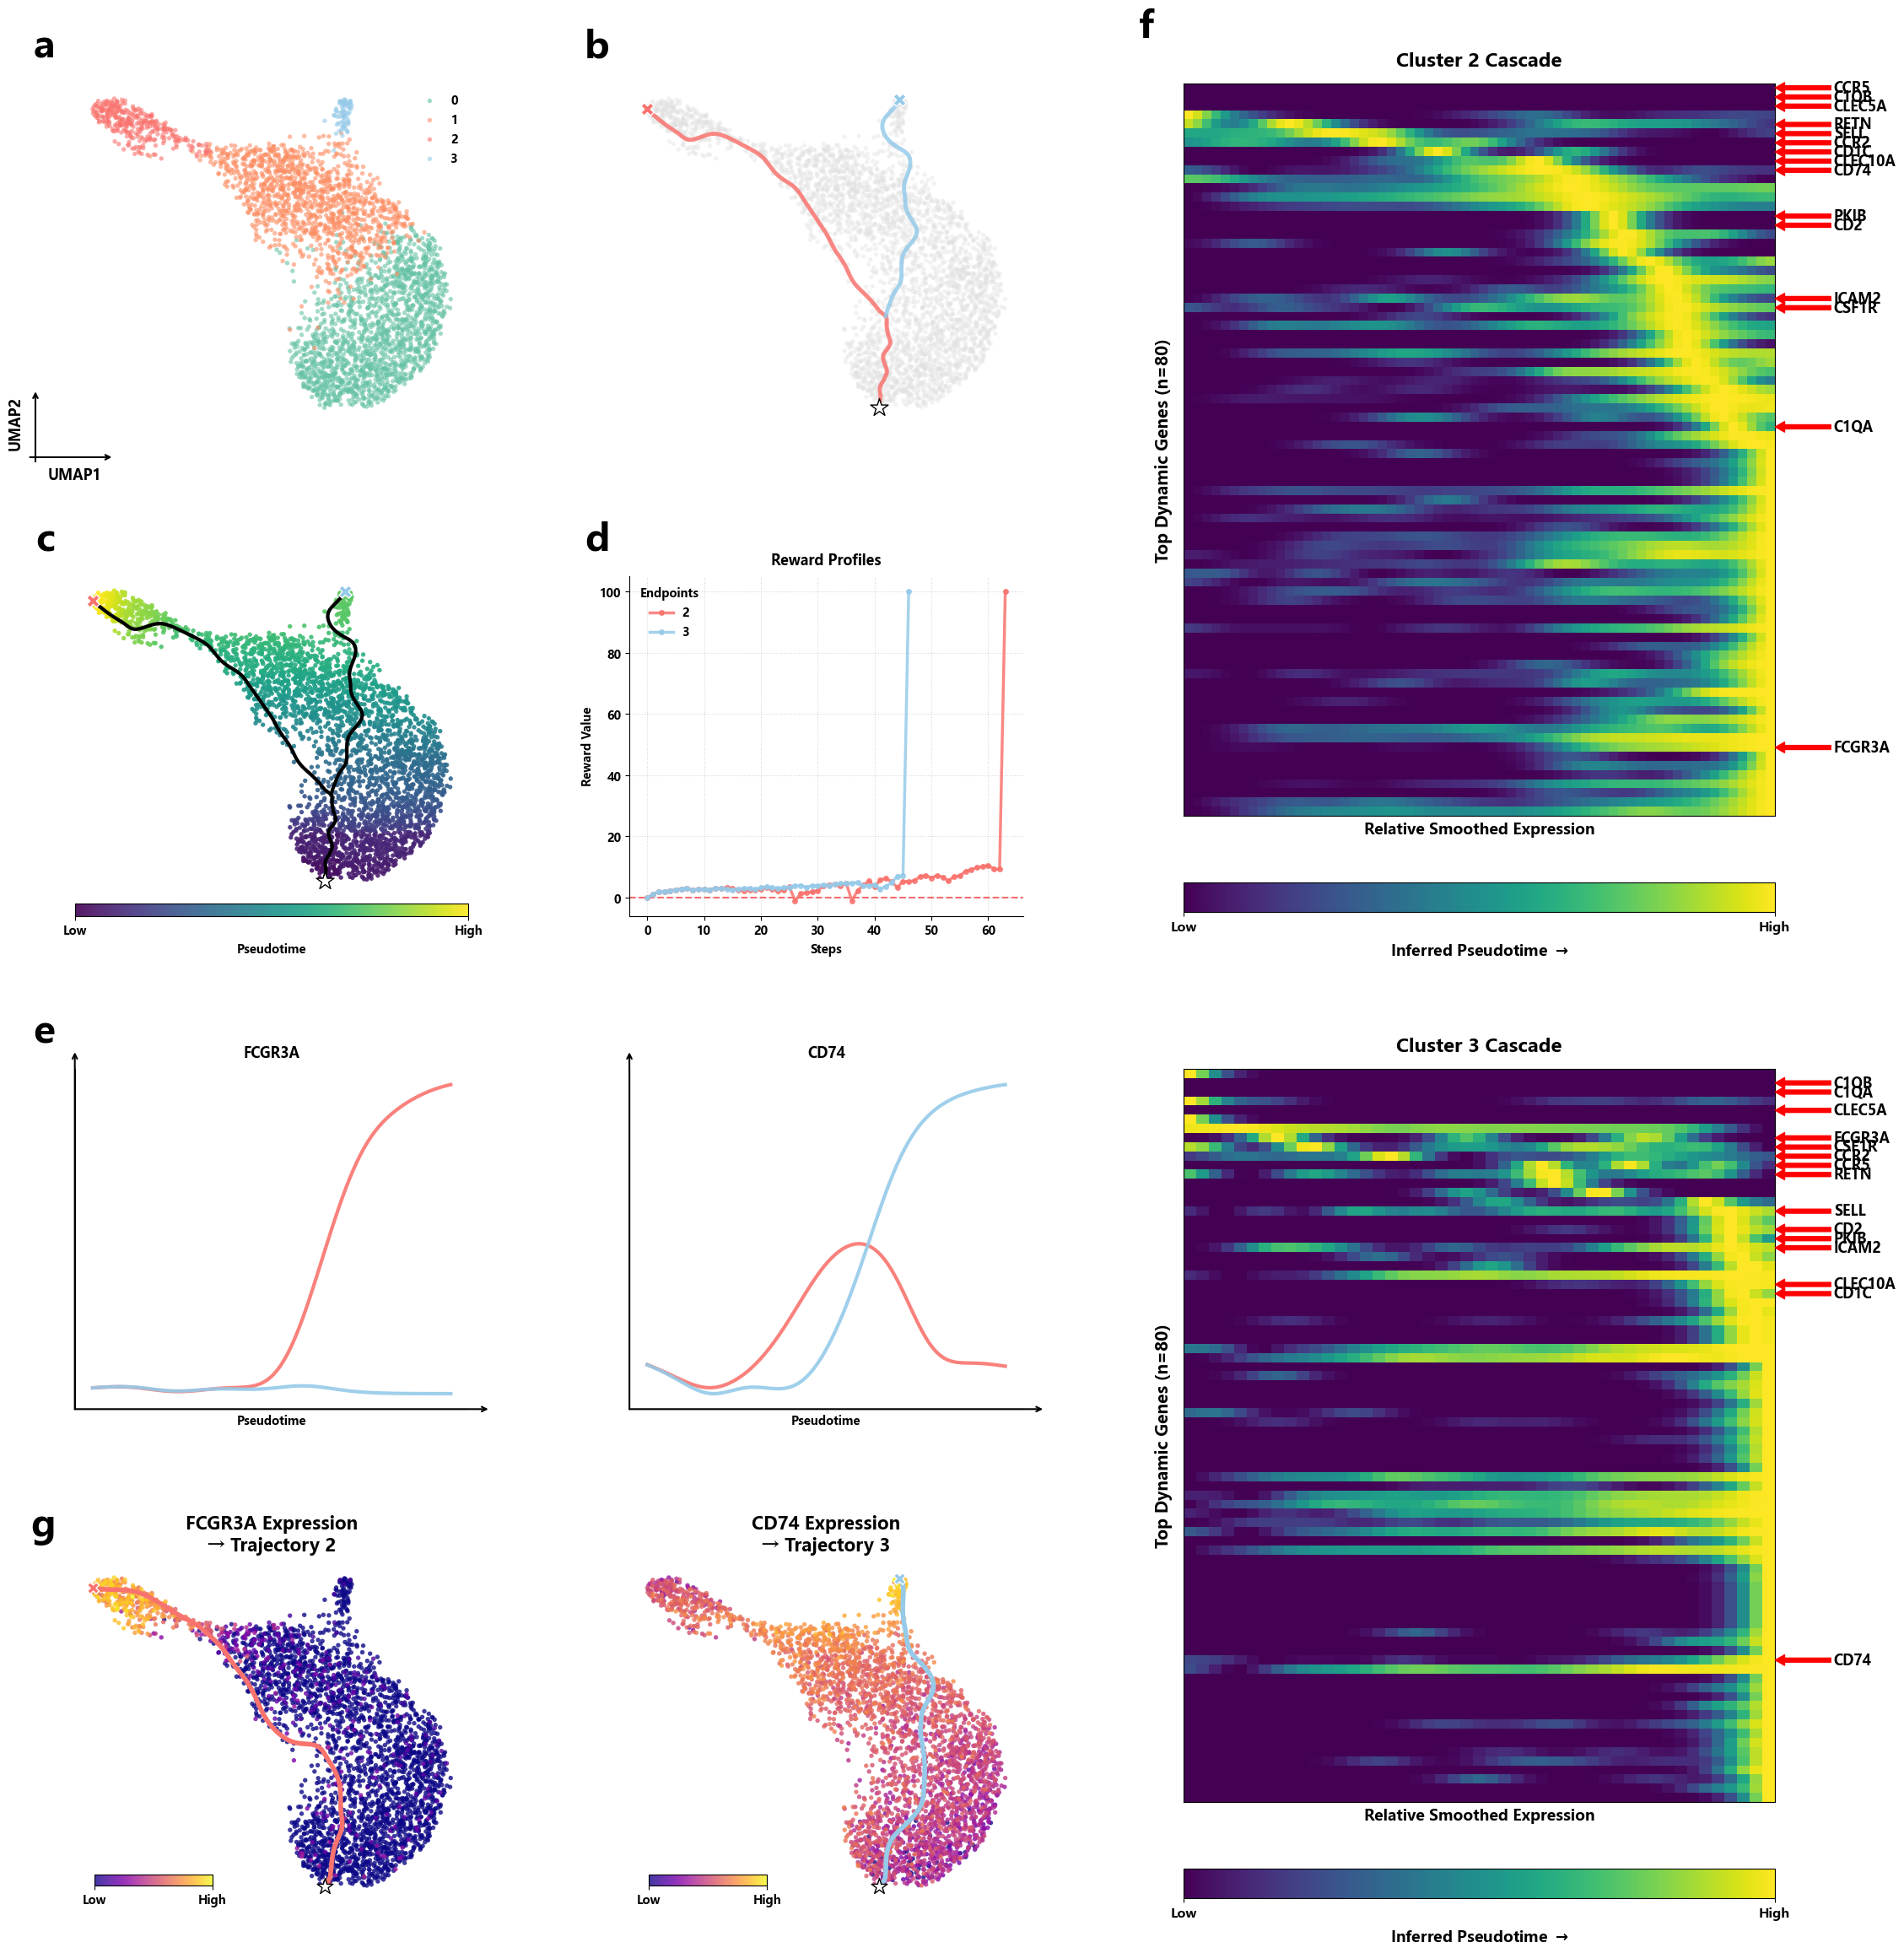

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import seaborn as sns
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ==========================================
# Global configuration and styling constants
# ==========================================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial Unicode MS', 'SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

START_MARKER = '*'
START_SIZE = 250
START_COLOR = 'white'
START_EDGE = 'black'
END_MARKER = 'X'
END_SIZE = 120

cluster_key = "cluster"

# Extract global variables
umap_coords = adata.obsm['X_umap'][:, :2]
cell_types_arr = np.array(adata.obs[cluster_key].astype(str))
start_idx = result['start_index']
ends_idx = result['endpoint_indices']
global_pt = results['rf_pseudotime'] 
dijkstra_paths = dijkstra_paths

smooth_path_b = True 
smooth_path_c = True 

# ==========================================
# Explicit colors for target lineages
# ==========================================
TARGET_LINEAGES = ['2', '3']
EXPLICIT_COLORS = {
    '2': '#f9736e',
    '3': '#95CAE9'
}

# Assign colors for other background types
unique_cell_types = np.unique(cell_types_arr)
global_palette = sns.color_palette("Set2", len(unique_cell_types))
GLOBAL_COLOR_MAP = {ctype: mpl.colors.to_hex(color) for ctype, color in zip(unique_cell_types, global_palette)}
GLOBAL_COLOR_MAP.update(EXPLICIT_COLORS)

# ==========================================
# Helper functions: Path smoothing & Normalization
# ==========================================
def extract_and_smooth_tree(paths_dict, coords, num_points=100, sigma=3, smooth=False):
    """
    Extract graph segments and apply Gaussian smoothing.
    Returns smoothed segments, terminal flags, and original node lists per segment.
    """
    if paths_dict is None or len(paths_dict) == 0: return [], [], []
    clean_paths = {k: (v['path'] if isinstance(v, dict) else v) for k, v in paths_dict.items()}
    edges, leaves = set(), set()
    
    for path in clean_paths.values():
        for i in range(len(path) - 1): edges.add((path[i], path[i+1]))
        if len(path) > 0: leaves.add(path[-1])
            
    out_degree = {u: 0 for u, v in edges}
    for u, v in edges: out_degree[u] += 1
    
    segments, terminal_flags, covered_edges = [], [], set()
    segment_node_lists = [] 

    for path in clean_paths.values():
        if not path: continue
        curr_seg = [path[0]]
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            if (u, v) not in covered_edges:
                covered_edges.add((u, v))
                curr_seg.append(v)
                if out_degree.get(v, 0) != 1 or v in leaves:
                    segments.append(curr_seg)
                    terminal_flags.append(v in leaves)
                    segment_node_lists.append(curr_seg)
                    curr_seg = [v]
            else: 
                curr_seg = [v]
                
    res_segs = []
    for nodes in segments:
        raw = coords[nodes]
        valid_idx = [0]
        for i in range(1, len(raw)):
            if np.linalg.norm(raw[i] - raw[valid_idx[-1]]) > 1e-4: valid_idx.append(i)
        uni = raw[valid_idx]
        if len(uni) < 3 or not smooth:
            res_segs.append(uni); continue
            
        diffs = np.diff(uni, axis=0)
        arc = np.concatenate(([0], np.cumsum(np.linalg.norm(diffs, axis=1))))
        if arc[-1] > 0: arc /= arc[-1]
        
        u_new = np.linspace(0, 1, num_points)
        smoothed = []
        for d in range(coords.shape[1]):
            f = interp1d(arc, uni[:, d], kind='linear')
            ds = gaussian_filter1d(f(u_new), sigma=sigma)
            ds[0], ds[-1] = uni[0, d], uni[-1, d]
            smoothed.append(ds)
        res_segs.append(np.column_stack(smoothed))
        
    return res_segs, terminal_flags, segment_node_lists


def normalize_pt_array(pt_array):
    """Min-max normalization for valid pseudotime values."""
    pt_norm = np.copy(pt_array).astype(float)
    mask = (pt_norm >= 0) & np.isfinite(pt_norm)
    if np.any(mask):
        pmin, pmax = np.min(pt_norm[mask]), np.max(pt_norm[mask])
        if pmax > pmin: pt_norm[mask] = (pt_norm[mask] - pmin) / (pmax - pmin)
    return pt_norm

# ==========================================
# Pre-computation: Target paths and segment processing
# ==========================================
# Extract complete path dictionary for target lineages
all_target_paths = {}
for t_name in TARGET_LINEAGES:
    match = [k for k, v in dijkstra_paths.items() if str(cell_types_arr[k]) == str(t_name)]
    if match:
        all_target_paths[match[0]] = dijkstra_paths[match[0]]

# Execute pre-computation for smoothed segments and nodes
GLOBAL_SMOOTH_SEGS, GLOBAL_FLAGS, GLOBAL_NODE_LISTS = extract_and_smooth_tree(
    all_target_paths, umap_coords, smooth=True, sigma=3
)

# ==========================================
# Core Layout Configuration (GridSpec 4x3)
# ==========================================
fig = plt.figure(figsize=(26, 28)) 
gs = gridspec.GridSpec(4, 3, width_ratios=[1, 1, 1.5], height_ratios=[1, 1, 1, 1], wspace=0.35, hspace=0.45)

# Row 1 (Left)
ax_a = fig.add_subplot(gs[0, 0])  
ax_b = fig.add_subplot(gs[0, 1])  

# Row 2 (Left)
ax_c = fig.add_subplot(gs[1, 0])  
ax_d = fig.add_subplot(gs[1, 1])  

# Row 3 (Left): Gene dynamics curves
ax_e1 = fig.add_subplot(gs[2, 0])
ax_e2 = fig.add_subplot(gs[2, 1])
axes_e = [ax_e1, ax_e2]

# Row 4 (Left): Feature plot superimposed with trajectory
ax_g1 = fig.add_subplot(gs[3, 0])
ax_g2 = fig.add_subplot(gs[3, 1])
axes_g = [ax_g1, ax_g2]

# Right Column: Vertical waterfall plots spanning multiple rows
ax_f1 = fig.add_subplot(gs[0:2, 2]) 
ax_f2 = fig.add_subplot(gs[2:4, 2]) 
axes_f = [ax_f1, ax_f2]

# ==========================================
# Plot A: UMAP Scatter Plot
# ==========================================
for label in unique_cell_types:
    mask = cell_types_arr == label
    c_color = GLOBAL_COLOR_MAP.get(str(label), 'gray') 
    ax_a.scatter(umap_coords[mask, 0], umap_coords[mask, 1], 
                 c=c_color, label=f'{label}', alpha=0.6, s=15, edgecolors='none')

ax_a.set_xticks([])
ax_a.set_yticks([])
for spine in ax_a.spines.values(): spine.set_visible(False)

ax_a.legend(loc='upper right', borderaxespad=0.5, frameon=False)

# UMAP directional arrows
origin_x, origin_y = -0.1, -0.1
cross_offset = 0.02
ax_a.annotate("", xy=(origin_x + 0.2, origin_y), xytext=(origin_x - cross_offset, origin_y), xycoords='axes fraction', arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax_a.annotate("", xy=(origin_x, origin_y + 0.2), xytext=(origin_x, origin_y - cross_offset), xycoords='axes fraction', arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax_a.text(origin_x + 0.1, origin_y - 0.03, "UMAP1", transform=ax_a.transAxes, ha='center', va='top', fontsize=12)
ax_a.text(origin_x - 0.03, origin_y + 0.1, "UMAP2", transform=ax_a.transAxes, ha='right', va='center', rotation=90, fontsize=12)

# ==========================================
# Plot B: Path Visualization 
# ==========================================
ax_b.scatter(umap_coords[:, 0], umap_coords[:, 1], c='#e0e0e0', alpha=0.4, s=15, edgecolors='none')
ax_b.scatter(umap_coords[start_idx, 0], umap_coords[start_idx, 1], fc=START_COLOR, ec=START_EDGE, marker=START_MARKER, s=START_SIZE, zorder=15)

for seg, nodes in zip(GLOBAL_SMOOTH_SEGS, GLOBAL_NODE_LISTS):
    # Retrieve active lineages sharing this segment
    belonging_indices = [e for e, p in all_target_paths.items() if all(n in p for n in nodes)]
    belonging_labels = [cell_types_arr[e] for e in belonging_indices]
    active_labels = [l for l in belonging_labels if l in TARGET_LINEAGES]
    
    if not active_labels: continue 
        
    # Main trunk logic: Use the first explicitly defined color
    if len(active_labels) > 1:
        line_color = EXPLICIT_COLORS[TARGET_LINEAGES[0]]
    # Branch logic: Use respective lineage color
    else:
        line_color = EXPLICIT_COLORS[active_labels[0]]
        
    ax_b.plot(seg[:, 0], seg[:, 1], c=line_color, linewidth=3.5, alpha=0.85, zorder=10)

# Draw endpoints for target lineages
for end_idx in ends_idx:
    label = cell_types_arr[end_idx]
    if label in TARGET_LINEAGES:
        ax_b.scatter(umap_coords[end_idx, 0], umap_coords[end_idx, 1], 
                     c=EXPLICIT_COLORS[label], 
                     s=END_SIZE, marker=END_MARKER, edgecolors='white', zorder=12)

ax_b.axis('off')

# ==========================================
# Plot C: Pseudotime & Global Black Skeleton
# ==========================================
pt_norm = normalize_pt_array(global_pt)
sc_c = ax_c.scatter(umap_coords[:, 0], umap_coords[:, 1], c=pt_norm, cmap='viridis', s=15, alpha=0.9, edgecolors='none')

for seg in GLOBAL_SMOOTH_SEGS:
    ax_c.plot(seg[:, 0], seg[:, 1], color='black', linewidth=3, zorder=10)

for end_idx in ends_idx:
    label = cell_types_arr[end_idx]
    if label in TARGET_LINEAGES:
        ax_c.scatter(umap_coords[end_idx, 0], umap_coords[end_idx, 1], 
                     color=EXPLICIT_COLORS[label], marker=END_MARKER, 
                     s=END_SIZE, zorder=12, edgecolors='white')

ax_c.scatter(umap_coords[start_idx, 0], umap_coords[start_idx, 1], fc=START_COLOR, ec=START_EDGE, marker=START_MARKER, s=START_SIZE, zorder=15)
ax_c.axis('off')

# Pseudotime Colorbar
divider = make_axes_locatable(ax_c)
cax = divider.append_axes("bottom", size="4%", pad=0.1)
cbar = fig.colorbar(sc_c, cax=cax, orientation='horizontal')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.set_label('Pseudotime', fontsize=10)

# ==========================================
# Plot D: Combined Reward Profiles
# ==========================================
_, path_steps_dict = q_learner.calculate_path_rewards(dijkstra_paths)
for end_node, raw_rewards in path_steps_dict.items():
    real_label = str(cell_types_arr[end_node])
    if real_label not in TARGET_LINEAGES: continue

    c_color = EXPLICIT_COLORS[real_label]
    ax_d.plot(range(len(raw_rewards)), raw_rewards, marker='o', ms=4, lw=2.5, color=c_color, alpha=0.85, label=real_label)

ax_d.axhline(0, color='red', ls='--', lw=1.5, alpha=0.6, zorder=1) 
ax_d.set_title("Reward Profiles", pad=10)
ax_d.set_xlabel("Steps")
ax_d.set_ylabel("Reward Value")
ax_d.grid(True, ls=':', alpha=0.5)
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)
ax_d.legend(loc='best', frameon=False, fontsize=10, title="Endpoints")

# ==========================================
# Plot E: Gene Dynamics Curves
# ==========================================
target_genes = ['FCGR3A', 'CD74'] 

for i, (gene, ax) in enumerate(zip(target_genes, axes_e)):
    if gene not in adata.var_names: continue
    gene_idx = adata.var_names.get_loc(gene)
    expr_all = adata.X[:, gene_idx].toarray().flatten() if sp.issparse(adata.X) else adata.X[:, gene_idx].flatten()
    
    for end_node, path_cells in dijkstra_paths.items():
        end_type_name = str(cell_types_arr[end_node])
        if end_type_name not in TARGET_LINEAGES: continue
        if len(path_cells) < 10: continue
        
        pt_raw = global_pt[path_cells]
        expr_raw = expr_all[path_cells]
        
        # Unified absolute time grid (0 to 1)
        pt_grid = np.linspace(0, 1.0, 100)
        expr_grid = np.zeros_like(pt_grid)
        
        # Gaussian kernel regression (Nadaraya-Watson) for smoothing
        sigma_pt = 0.08 
        for j, t in enumerate(pt_grid):
            weights = np.exp(-0.5 * ((pt_raw - t) / sigma_pt)**2)
            weight_sum = np.sum(weights)
            if weight_sum > 0:
                expr_grid[j] = np.sum(weights * expr_raw) / weight_sum
            else:
                expr_grid[j] = 0
        
        c_color = EXPLICIT_COLORS[end_type_name]
        ax.plot(pt_grid, expr_grid, color=c_color, lw=3.0, alpha=0.9, label=end_type_name)
        
    ax.set_title(f"{gene}", pad=10)
    ax.set_xlabel("Pseudotime")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.annotate('', xy=(1.05, 0), xycoords='axes fraction', xytext=(0, 0), 
                arrowprops=dict(arrowstyle="->", color='black', lw=1.5, shrinkA=0, shrinkB=0))
    ax.annotate('', xy=(0, 1.05), xycoords='axes fraction', xytext=(0, 0), 
                arrowprops=dict(arrowstyle="->", color='black', lw=1.5, shrinkA=0, shrinkB=0))
    
# ==========================================
# Plot G: Feature Plot with Superimposed Trajectory
# ==========================================
target_pairs = [('FCGR3A', '2'), ('CD74', '3')]
type_to_node = {str(cell_types_arr[node]): node for node in dijkstra_paths.keys()}

for idx, ((gene, target_type), ax) in enumerate(zip(target_pairs, axes_g)):
    if gene not in adata.var_names or target_type not in type_to_node: continue
        
    gene_idx = adata.var_names.get_loc(gene)
    expr_all = adata.X[:, gene_idx].toarray().flatten() if sp.issparse(adata.X) else adata.X[:, gene_idx].flatten()
    
    order = np.argsort(expr_all)
    expr_sorted = expr_all[order]
    coords_sorted = umap_coords[order]
    
    sc_plot = ax.scatter(coords_sorted[:, 0], coords_sorted[:, 1], c=expr_sorted, cmap='plasma', s=15, alpha=0.8, edgecolors='none', zorder=1)

    end_node = type_to_node[target_type]
    if end_node in dijkstra_paths:
        path_nodes = dijkstra_paths[end_node]
        segs, _, _ = extract_and_smooth_tree({end_node: path_nodes}, umap_coords, smooth=True)
        path_coords = segs[0] if segs else umap_coords[path_nodes]
        
        line_color = EXPLICIT_COLORS.get(target_type, 'black')
        ax.plot(path_coords[:, 0], path_coords[:, 1], color=line_color, linewidth=4.0, zorder=10)
        ax.scatter(path_coords[0, 0], path_coords[0, 1], c='white', edgecolors='black', marker='*', s=200, zorder=15)
        ax.scatter(path_coords[-1, 0], path_coords[-1, 1], c=line_color, edgecolors='white', marker='X', s=100, zorder=15)

    ax.set_title(f"{gene} Expression\n\u2192 Trajectory {target_type}", fontsize=15, pad=10)
    ax.axis('off')
    
    cax = ax.inset_axes([0.05, 0.05, 0.3, 0.03])
    cbar = fig.colorbar(sc_plot, cax=cax, orientation='horizontal')
    cbar.set_ticks([expr_sorted.min(), expr_sorted.max()])
    cbar.set_ticklabels(['Low', 'High'])
    cbar.ax.tick_params(labelsize=10)

# ==========================================
# Plot F: Vertical Waterfall Plots
# ==========================================
selected_ends_f = [type_to_node[t] for t in TARGET_LINEAGES if t in type_to_node]
classic_markers = [
    'CLEC5A', 'RETN', 'CCR2', 'SELL',               # Stage 0
    'CSF1R', 'ICAM2',                               # Stage 1
    'C1QA', 'C1QB', 'FCGR3A',                       # Stage 2
    'CCR5', 'CD2', 'CLEC10A', 'CD74', 'CD1C', 'PKIB' # Stage 3
]
valid_must_have = [g for g in classic_markers if g in adata.var_names]
top_n_genes = 80

for idx, (end_node, ax) in enumerate(zip(selected_ends_f, axes_f)):
    path_cells = dijkstra_paths[end_node]
    end_type = cell_types_arr[end_node]
    if len(path_cells) < 10: continue
        
    branch_adata = adata[path_cells, :]
    branch_pt = global_pt[path_cells]
    expr_mat = branch_adata.X.toarray() if sp.issparse(branch_adata.X) else branch_adata.X
        
    sort_idx = np.argsort(branch_pt)
    sorted_expr = expr_mat[sort_idx, :]
    
    dynamic_sigma = max(2, int(len(path_cells) * 0.05))
    smoothed_expr = gaussian_filter1d(sorted_expr, sigma=dynamic_sigma, axis=0)
    
    amplitudes = np.max(smoothed_expr, axis=0) - np.min(smoothed_expr, axis=0)
    mean_expr = np.mean(smoothed_expr, axis=0)
    valid_genes_mask = mean_expr > 0.01
    amplitudes[~valid_genes_mask] = 0
    top_gene_indices = np.argsort(amplitudes)[-top_n_genes:].tolist()
    
    highlight_genes = []
    if valid_must_have:
        var_names_list = branch_adata.var_names.tolist()
        for target_gene in valid_must_have:
            if target_gene in var_names_list:
                highlight_genes.append(target_gene)
                gene_idx = var_names_list.index(target_gene)
                if gene_idx not in top_gene_indices:
                    top_gene_indices.pop(0) 
                    top_gene_indices.append(gene_idx)
    else:
        highlight_genes = branch_adata.var_names[top_gene_indices[-3:]].tolist()
        
    selected_genes = branch_adata.var_names[top_gene_indices].tolist()
    final_smoothed_expr = smoothed_expr[:, top_gene_indices]
    
    f_min, f_max = final_smoothed_expr.min(axis=0), final_smoothed_expr.max(axis=0)
    scaled_expr = (final_smoothed_expr - f_min) / (f_max - f_min + 1e-9)
    peak_idx = np.argmax(scaled_expr, axis=0)
    gene_sort = np.argsort(peak_idx)
    scaled_expr_sorted = scaled_expr[:, gene_sort]
    sorted_gene_names = np.array(selected_genes)[gene_sort]
    
    im = ax.imshow(scaled_expr_sorted.T, aspect='auto', cmap='viridis', interpolation='nearest')
    ax.set_title(f"Cluster {end_type} Cascade", fontsize=16, pad=15)
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.set_ylabel(f"Top Dynamic Genes (n={top_n_genes})", fontsize=14, labelpad=10)
    ax.set_xlabel("Relative Smoothed Expression", fontsize=13, labelpad=5)
    
    for hg in highlight_genes:
        if hg in sorted_gene_names:
            y_pos = np.where(sorted_gene_names == hg)[0][0]
            ax.annotate(hg, xy=(1.0, y_pos), xycoords=('axes fraction', 'data'),
                        xytext=(1.10, y_pos), textcoords=('axes fraction', 'data'),
                        arrowprops=dict(facecolor='red', edgecolor='red', width=3.5, headwidth=9, headlength=8, shrink=0.01),
                        va='center', ha='left', fontsize=12, color='black')

    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.04, pad=0.08)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['Low', 'High'])
    cbar.ax.tick_params(labelsize=11)
    cbar.ax.set_xlabel("Inferred Pseudotime $\\rightarrow$", fontsize=13, labelpad=8)

# ==========================================
# Append uniform panel labels (a-g)
# ==========================================
axes_label_map = zip(['a', 'b', 'c', 'd', 'e', 'g', 'f'], 
                     [ax_a, ax_b, ax_c, ax_d, axes_e[0], axes_g[0], ax_f1, ax_f2])
for label, ax in axes_label_map:
    ax.text(-0.05, 1.05, label, transform=ax.transAxes, fontsize=32, fontweight=1000, va='bottom', ha='right')

plt.show()

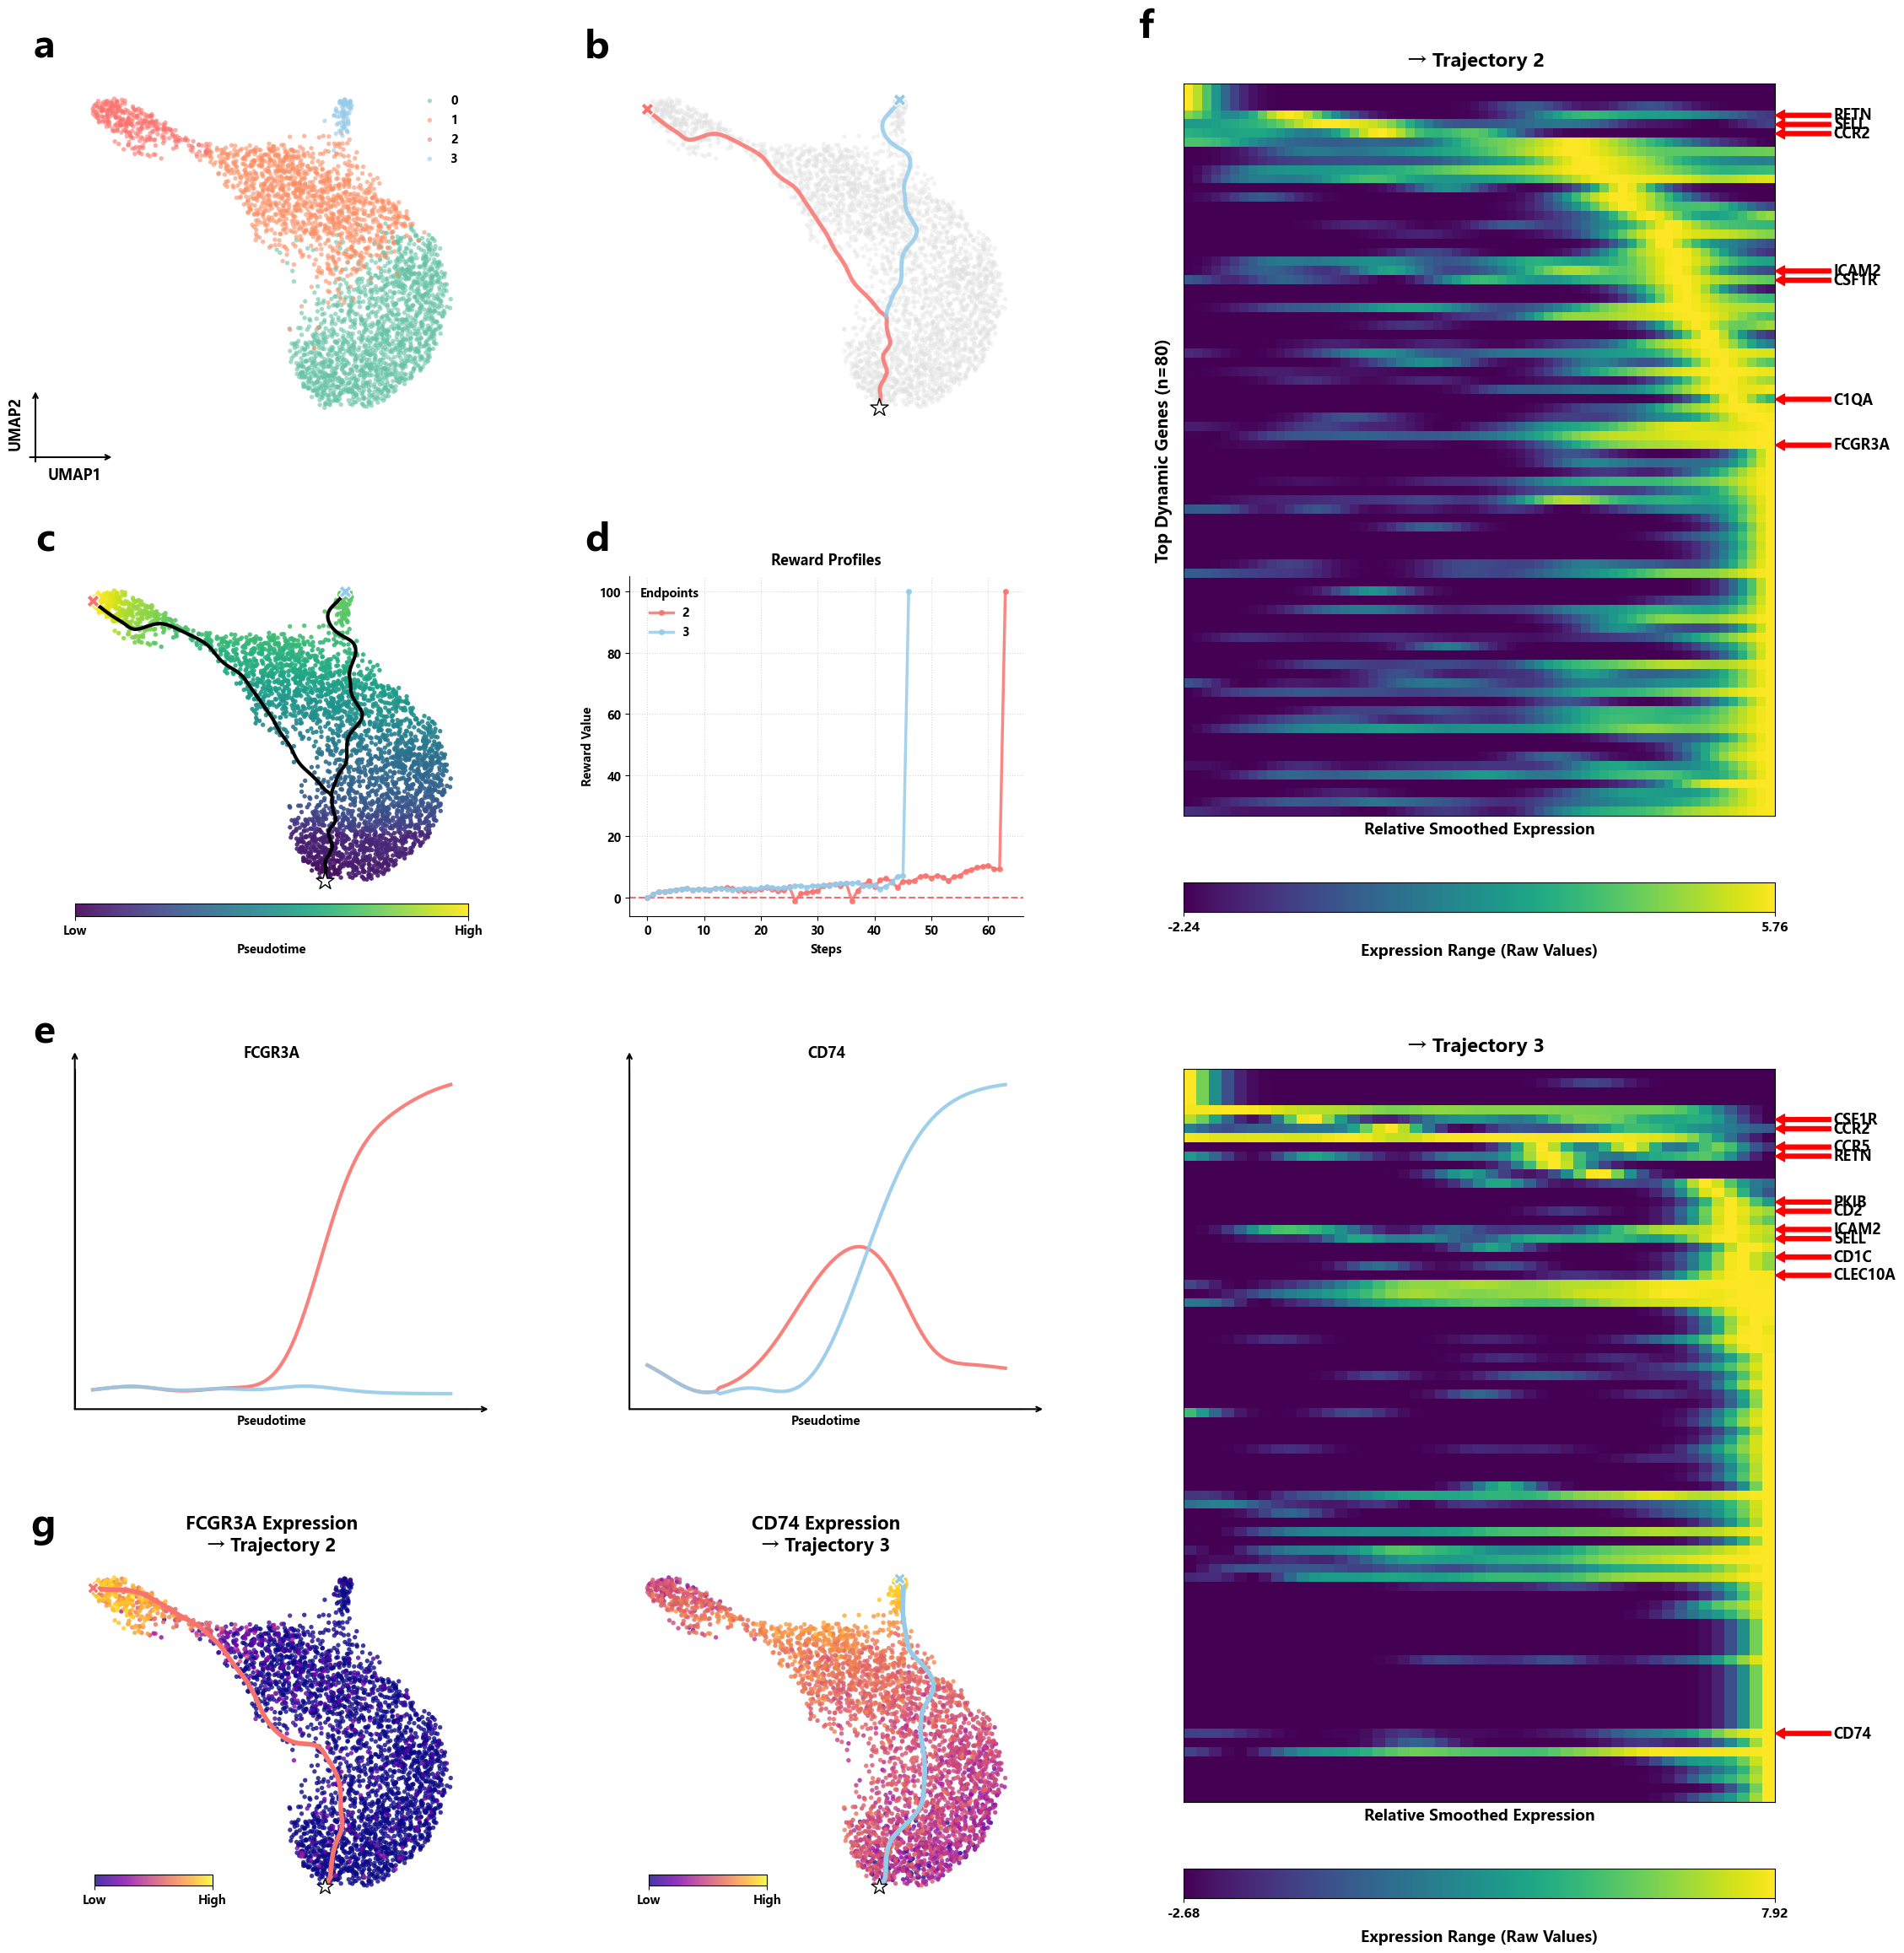

In [107]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import seaborn as sns
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ==========================================
# 🌟 全局配置与样式常量
# ==========================================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial Unicode MS', 'SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

START_MARKER = '*'
START_SIZE = 250
START_COLOR = 'white'
START_EDGE = 'black'
END_MARKER = 'X'
END_SIZE = 120

cluster_key = "cluster" # ⭐ 已替换为 cluster

# ==========================================
# 🌟 绝对原封不动的变量提取 (绝不污染 C 图)
# ==========================================
umap_coords = adata.obsm['X_umap'][:, :2]
cell_types_arr = np.array(adata.obs[cluster_key].astype(str))
start_idx = result['start_index']
ends_idx = result['endpoint_indices']
global_pt = results['rf_pseudotime']  # 👈 完璧归赵！保持原样，保护 C、D 图
dijkstra_paths = dijkstra_paths

smooth_path_b = True 
smooth_path_c = True 

# ==========================================
# ⭐ 强制指定两组终点的颜色与顺序
# ==========================================
TARGET_LINEAGES = ['2', '3']
EXPLICIT_COLORS = {
    '2': '#f9736e',
    '3': '#95CAE9'
}

# 补充其他背景类型的颜色
unique_cell_types = np.unique(cell_types_arr)
global_palette = sns.color_palette("Set2", len(unique_cell_types))
GLOBAL_COLOR_MAP = {ctype: mpl.colors.to_hex(color) for ctype, color in zip(unique_cell_types, global_palette)}
GLOBAL_COLOR_MAP.update(EXPLICIT_COLORS)

# ==========================================
# 工具函数：路径平滑与归一化
# ==========================================
def extract_and_smooth_tree(paths_dict, coords, num_points=100, sigma=3, smooth=False):
    if paths_dict is None or len(paths_dict) == 0: return [], []
    clean_paths = {k: (v['path'] if isinstance(v, dict) else v) for k, v in paths_dict.items()}
    edges, leaves = set(), set()
    for path in clean_paths.values():
        for i in range(len(path) - 1): edges.add((path[i], path[i+1]))
        if len(path) > 0: leaves.add(path[-1])
    out_degree = {u: 0 for u, v in edges}
    for u, v in edges: out_degree[u] += 1
    
    segments, terminal_flags, covered_edges = [], [], set()
    for path in clean_paths.values():
        if not path: continue
        curr_seg = [path[0]]
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            if (u, v) not in covered_edges:
                covered_edges.add((u, v))
                curr_seg.append(v)
                if out_degree.get(v, 0) != 1 or v in leaves:
                    segments.append(curr_seg); terminal_flags.append(v in leaves); curr_seg = [v]
            else: curr_seg = [v]
            
    res_segs = []
    for nodes in segments:
        raw = coords[nodes]
        valid_idx = [0]
        for i in range(1, len(raw)):
            if np.linalg.norm(raw[i] - raw[valid_idx[-1]]) > 1e-4: valid_idx.append(i)
        uni = raw[valid_idx]
        if len(uni) < 3 or not smooth:
            res_segs.append(uni); continue
        diffs = np.diff(uni, axis=0)
        arc = np.concatenate(([0], np.cumsum(np.linalg.norm(diffs, axis=1))))
        if arc[-1] > 0: arc /= arc[-1]
        u_new = np.linspace(0, 1, num_points)
        smoothed = []
        for d in range(coords.shape[1]):
            f = interp1d(arc, uni[:, d], kind='linear')
            ds = gaussian_filter1d(f(u_new), sigma=sigma)
            ds[0], ds[-1] = uni[0, d], uni[-1, d]
            smoothed.append(ds)
        res_segs.append(np.column_stack(smoothed))
    return res_segs, terminal_flags

def normalize_pt_array(pt_array):
    pt_norm = np.copy(pt_array).astype(float)
    mask = (pt_norm >= 0) & np.isfinite(pt_norm)
    if np.any(mask):
        pmin, pmax = np.min(pt_norm[mask]), np.max(pt_norm[mask])
        if pmax > pmin: pt_norm[mask] = (pt_norm[mask] - pmin) / (pmax - pmin)
    return pt_norm

# ==========================================
# 🌟 核心布局：4行 x 3列 (巧妙运用 GridSpec)
# ==========================================
fig = plt.figure(figsize=(26, 28))  # 整体增高增宽
# width_ratios: 前两列各占1，第三列（瀑布流）占1.5保证够宽
gs = gridspec.GridSpec(4, 3, width_ratios=[1, 1, 1.5], height_ratios=[1, 1, 1, 1], wspace=0.35, hspace=0.45)

# 🟢 第 1 行 (左侧)
ax_a = fig.add_subplot(gs[0, 0])  
ax_b = fig.add_subplot(gs[0, 1])  

# 🟢 第 2 行 (左侧)
ax_c = fig.add_subplot(gs[1, 0])  
ax_d = fig.add_subplot(gs[1, 1])  

# 🟢 第 3 行 (左侧)：e图动力学曲线
ax_e1 = fig.add_subplot(gs[2, 0])
ax_e2 = fig.add_subplot(gs[2, 1])
axes_e = [ax_e1, ax_e2]

# 🟢 第 4 行 (左侧)：新增的 g 图 (Feature plot 叠加轨迹)
ax_g1 = fig.add_subplot(gs[3, 0])
ax_g2 = fig.add_subplot(gs[3, 1])
axes_g = [ax_g1, ax_g2]

# 🟢 右侧 1 列：f 图瀑布流 (各跨越 2 行的高度)
ax_f1 = fig.add_subplot(gs[0:2, 2]) # 占据 第1、2行 的第3列
ax_f2 = fig.add_subplot(gs[2:4, 2]) # 占据 第3、4行 的第3列
axes_f = [ax_f1, ax_f2]

# ==========================================
# 图 a: UMAP 散点图
# ==========================================
for label in unique_cell_types:
    mask = cell_types_arr == label
    c_color = GLOBAL_COLOR_MAP.get(str(label), 'gray') 
    ax_a.scatter(umap_coords[mask, 0], umap_coords[mask, 1], 
                 c=c_color, label=f'{label}', alpha=0.6, s=15, edgecolors='none')

ax_a.set_xticks([])
ax_a.set_yticks([])
for spine in ax_a.spines.values(): spine.set_visible(False)

ax_a.legend(loc='upper right', borderaxespad=0.5, frameon=False)

origin_x, origin_y = -0.1, -0.1
cross_offset = 0.02
ax_a.annotate("", xy=(origin_x + 0.2, origin_y), xytext=(origin_x - cross_offset, origin_y), xycoords='axes fraction', arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax_a.annotate("", xy=(origin_x, origin_y + 0.2), xytext=(origin_x, origin_y - cross_offset), xycoords='axes fraction', arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax_a.text(origin_x + 0.1, origin_y - 0.03, "UMAP1", transform=ax_a.transAxes, ha='center', va='top', fontsize=12)
ax_a.text(origin_x - 0.03, origin_y + 0.1, "UMAP2", transform=ax_a.transAxes, ha='right', va='center', rotation=90, fontsize=12)

# ------------------------------------------
# 图 b: 路径可视化 (主干使用第一个指定分支的颜色)
# ------------------------------------------
ax_b.scatter(umap_coords[:, 0], umap_coords[:, 1], c='#e0e0e0', alpha=0.4, s=15, edgecolors='none')
ax_b.scatter(umap_coords[start_idx, 0], umap_coords[start_idx, 1], fc=START_COLOR, ec=START_EDGE, marker=START_MARKER, s=START_SIZE, zorder=15)

for seg, nodes in zip(GLOBAL_SMOOTH_SEGS, GLOBAL_NODE_LISTS):
    belonging_indices = [e for e, p in all_target_paths.items() if all(n in p for n in nodes)]
    belonging_labels = [cell_types_arr[e] for e in belonging_indices]
    active_labels = [l for l in belonging_labels if l in TARGET_LINEAGES]
    
    if not active_labels:
        continue 
        
    if len(active_labels) > 1:
        line_color = EXPLICIT_COLORS[TARGET_LINEAGES[0]]
    else:
        line_color = EXPLICIT_COLORS[active_labels[0]]
        
    ax_b.plot(seg[:, 0], seg[:, 1], c=line_color, linewidth=3.5, alpha=0.85, zorder=10)

for end_idx in ends_idx:
    label = cell_types_arr[end_idx]
    if label in TARGET_LINEAGES:
        ax_b.scatter(umap_coords[end_idx, 0], umap_coords[end_idx, 1], 
                     c=EXPLICIT_COLORS[label], 
                     s=END_SIZE, marker=END_MARKER, edgecolors='white', zorder=12)

ax_b.axis('off')

# ------------------------------------------
# 图 c: 伪时间与合并黑骨架 (主干绝对唯一)
# ------------------------------------------
pt_norm = normalize_pt_array(global_pt)
sc_c = ax_c.scatter(umap_coords[:, 0], umap_coords[:, 1], c=pt_norm, cmap='viridis', s=15, alpha=0.9, edgecolors='none')

for seg in GLOBAL_SMOOTH_SEGS:
    ax_c.plot(seg[:, 0], seg[:, 1], color='black', linewidth=3, zorder=10)

for end_idx in ends_idx:
    label = cell_types_arr[end_idx]
    if label in TARGET_LINEAGES:
        ax_c.scatter(umap_coords[end_idx, 0], umap_coords[end_idx, 1], 
                     color=EXPLICIT_COLORS[label], marker=END_MARKER, 
                     s=END_SIZE, zorder=12, edgecolors='white')

ax_c.scatter(umap_coords[start_idx, 0], umap_coords[start_idx, 1], fc=START_COLOR, ec=START_EDGE, marker=START_MARKER, s=START_SIZE, zorder=15)
ax_c.axis('off')

divider = make_axes_locatable(ax_c)
cax = divider.append_axes("bottom", size="4%", pad=0.1)
cbar = fig.colorbar(sc_c, cax=cax, orientation='horizontal')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.set_label('Pseudotime', fontsize=10)

# ==========================================
# 图 d: 合并的 Reward 折线图
# ==========================================
_, path_steps_dict = q_learner.calculate_path_rewards(dijkstra_paths)
for end_node, raw_rewards in path_steps_dict.items():
    real_label = str(cell_types_arr[end_node])
    if real_label not in TARGET_LINEAGES: continue

    c_color = EXPLICIT_COLORS[real_label]
    ax_d.plot(range(len(raw_rewards)), raw_rewards, marker='o', ms=4, lw=2.5, color=c_color, alpha=0.85, label=real_label)

ax_d.axhline(0, color='red', ls='--', lw=1.5, alpha=0.6, zorder=1) 
ax_d.set_title("Reward Profiles", pad=10)
ax_d.set_xlabel("Steps")
ax_d.set_ylabel("Reward Value")
ax_d.grid(True, ls=':', alpha=0.5)
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)
ax_d.legend(loc='best', frameon=False, fontsize=10, title="Endpoints")


# ==========================================
# 🌟 (专属修改区) 仅供 E 和 F 使用的绝对时间隔离提取
# ==========================================
# 专门拉取 global_pseudotime，且彻底归一化，确保所有共轨计算绝不错位
ef_pt_norm = results['global_pseudotime']

type_to_node_ef = {str(cell_types_arr[node]): node for node in dijkstra_paths.keys()}
selected_ends_ef = [type_to_node_ef[t] for t in TARGET_LINEAGES if t in type_to_node_ef]

if len(selected_ends_ef) >= 2:
    path_A_cells = dijkstra_paths[selected_ends_ef[0]]
    path_B_cells = dijkstra_paths[selected_ends_ef[1]]
    shared_cells = list(set(path_A_cells) & set(path_B_cells))
    t_split = np.max(ef_pt_norm[shared_cells]) if shared_cells else 0.5
else:
    t_split = 0.5

pt_grid = np.linspace(0, 1.0, 100)
split_idx = np.searchsorted(pt_grid, t_split)


# ==========================================
# 图 e: 基因动力学曲线 
# ==========================================
target_genes = ['FCGR3A', 'CD74'] 

for i, (gene, ax) in enumerate(zip(target_genes, axes_e)):
    if gene not in adata.var_names: continue
    gene_idx = adata.var_names.get_loc(gene)
    expr_all = adata.X[:, gene_idx].toarray().flatten() if sp.issparse(adata.X) else adata.X[:, gene_idx].flatten()
    
    smooth_curves = {}
    for end_node in selected_ends_ef:
        end_type_name = str(cell_types_arr[end_node])
        path_cells = dijkstra_paths[end_node]
        if len(path_cells) < 10: continue
        
        # 🌟 内部计算：使用绝对网格上的 ef_pt_norm
        pt_raw = ef_pt_norm[path_cells]
        expr_raw = expr_all[path_cells]
        expr_grid = np.zeros_like(pt_grid)
        sigma_pt = 0.08 
        
        for j, t in enumerate(pt_grid):
            weights = np.exp(-0.5 * ((pt_raw - t) / sigma_pt)**2)
            weight_sum = np.sum(weights)
            expr_grid[j] = np.sum(weights * expr_raw) / weight_sum if weight_sum > 0 else 0
            
        smooth_curves[end_type_name] = expr_grid

    # 🌟 强制合并主干：分支点之前的值完全平均，确保图表共轨100%重叠
    if len(TARGET_LINEAGES) == 2:
        name_A, name_B = TARGET_LINEAGES[0], TARGET_LINEAGES[1]
        if name_A in smooth_curves and name_B in smooth_curves:
            trunk_avg = (smooth_curves[name_A][:split_idx] + smooth_curves[name_B][:split_idx]) / 2
            smooth_curves[name_A][:split_idx] = trunk_avg
            smooth_curves[name_B][:split_idx] = trunk_avg
            
    for end_type_name, grid_vals in smooth_curves.items():
        c_color = EXPLICIT_COLORS[end_type_name]
        ax.plot(pt_grid, grid_vals, color=c_color, lw=3.0, alpha=0.9, label=end_type_name)
        
    ax.set_title(f"{gene}", pad=10)
    ax.set_xlabel("Pseudotime")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.annotate('', xy=(1.05, 0), xycoords='axes fraction', xytext=(0, 0), 
                arrowprops=dict(arrowstyle="->", color='black', lw=1.5, shrinkA=0, shrinkB=0))
    ax.annotate('', xy=(0, 1.05), xycoords='axes fraction', xytext=(0, 0), 
                arrowprops=dict(arrowstyle="->", color='black', lw=1.5, shrinkA=0, shrinkB=0))
    
# ==========================================
# 图 g: Feature Plot 叠加彩色轨迹 (保持原封不动)
# ==========================================
target_pairs = [('FCGR3A', '2'), ('CD74', '3')]
type_to_node = {str(cell_types_arr[node]): node for node in dijkstra_paths.keys()}

for idx, ((gene, target_type), ax) in enumerate(zip(target_pairs, axes_g)):
    if gene not in adata.var_names or target_type not in type_to_node: continue
        
    gene_idx = adata.var_names.get_loc(gene)
    expr_all = adata.X[:, gene_idx].toarray().flatten() if sp.issparse(adata.X) else adata.X[:, gene_idx].flatten()
    
    order = np.argsort(expr_all)
    expr_sorted = expr_all[order]
    coords_sorted = umap_coords[order]
    
    sc_plot = ax.scatter(coords_sorted[:, 0], coords_sorted[:, 1], c=expr_sorted, cmap='plasma', s=15, alpha=0.8, edgecolors='none', zorder=1)

    end_node = type_to_node[target_type]
    if end_node in dijkstra_paths:
        path_nodes = dijkstra_paths[end_node]
        segs, _ = extract_and_smooth_tree({end_node: path_nodes}, umap_coords, smooth=True)
        path_coords = segs[0] if segs else umap_coords[path_nodes]
        
        line_color = EXPLICIT_COLORS.get(target_type, 'black')
        ax.plot(path_coords[:, 0], path_coords[:, 1], color=line_color, linewidth=4.0, zorder=10)
        ax.scatter(path_coords[0, 0], path_coords[0, 1], c='white', edgecolors='black', marker='*', s=200, zorder=15)
        ax.scatter(path_coords[-1, 0], path_coords[-1, 1], c=line_color, edgecolors='white', marker='X', s=100, zorder=15)

    ax.set_title(f"{gene} Expression\n\u2192 Trajectory {target_type}", fontsize=15, pad=10)
    ax.axis('off')
    
    cax = ax.inset_axes([0.05, 0.05, 0.3, 0.03])
    cbar = fig.colorbar(sc_plot, cax=cax, orientation='horizontal')
    cbar.set_ticks([expr_sorted.min(), expr_sorted.max()])
    cbar.set_ticklabels(['Low', 'High'])
    cbar.ax.tick_params(labelsize=10)

# ==========================================
# 图 f: 竖向排列的瀑布流 (纯净自然版 + 物理黑名单强行排他)
# ==========================================
# ==========================================
# 图 f: 竖向排列的瀑布流 (仅修改图例标签为数值)
# ==========================================
classic_markers = [
    # Stage 0
    'RETN', 'CCR2', 'SELL',               
    # Stage 1
    'CSF1R', 'ICAM2',                     
    # Stage 2
    'C1QA', 'FCGR3A',             
    # Stage 3
    'CCR5', 'CD2', 'CLEC10A', 'CD74', 'CD1C', 'PKIB' 
]
valid_must_have = [g for g in classic_markers if g in adata.var_names]
top_n_genes = 80

forbidden_dict = {
    '2': ['CCR5', 'CD2', 'CLEC10A', 'CD74', 'CD1C', 'PKIB'],
    '3': ['C1QA', 'C1QB', 'FCGR3A']
}

for idx, (end_node, ax) in enumerate(zip(selected_ends_f, axes_f)):
    path_cells = dijkstra_paths[end_node]
    end_type = str(cell_types_arr[end_node])
    if len(path_cells) < 10: continue
        
    branch_adata = adata[path_cells, :]
    
    branch_pt = ef_pt_norm[path_cells]
    expr_mat = branch_adata.X.toarray() if sp.issparse(branch_adata.X) else branch_adata.X
        
    sort_idx = np.argsort(branch_pt)
    sorted_expr = expr_mat[sort_idx, :]
    
    dynamic_sigma = max(2, int(len(path_cells) * 0.05))
    smoothed_expr = gaussian_filter1d(sorted_expr, sigma=dynamic_sigma, axis=0)
    
    amplitudes = np.max(smoothed_expr, axis=0) - np.min(smoothed_expr, axis=0)
    mean_expr = np.mean(smoothed_expr, axis=0)
    valid_genes_mask = mean_expr > 0.01
    amplitudes[~valid_genes_mask] = 0
    
    if end_type in forbidden_dict:
        for bad_gene in forbidden_dict[end_type]:
            if bad_gene in branch_adata.var_names:
                bad_idx = branch_adata.var_names.tolist().index(bad_gene)
                amplitudes[bad_idx] = 0  
                
    top_gene_indices = np.argsort(amplitudes)[-top_n_genes:].tolist()
    
    highlight_genes = []
    if valid_must_have:
        var_names_list = branch_adata.var_names.tolist()
        current_allowed_must_have = [g for g in valid_must_have if g not in forbidden_dict.get(end_type, [])]
        
        for target_gene in current_allowed_must_have:
            if target_gene in var_names_list:
                highlight_genes.append(target_gene)
                gene_idx = var_names_list.index(target_gene)
                if gene_idx not in top_gene_indices:
                    top_gene_indices.pop(0) 
                    top_gene_indices.append(gene_idx)
    else:
        highlight_genes = branch_adata.var_names[top_gene_indices[-3:]].tolist()
        
    selected_genes = branch_adata.var_names[top_gene_indices].tolist()
    final_smoothed_expr = smoothed_expr[:, top_gene_indices]
    
    # 获取原始数值的极值用于图例显示
    f_min_val, f_max_val = final_smoothed_expr.min(), final_smoothed_expr.max()
    
    # 归一化用于瀑布流视觉展示
    f_min, f_max = final_smoothed_expr.min(axis=0), final_smoothed_expr.max(axis=0)
    scaled_expr = (final_smoothed_expr - f_min) / (f_max - f_min + 1e-9)
    peak_idx = np.argmax(scaled_expr, axis=0)
    gene_sort = np.argsort(peak_idx)
    scaled_expr_sorted = scaled_expr[:, gene_sort]
    sorted_gene_names = np.array(selected_genes)[gene_sort]
    
    im = ax.imshow(scaled_expr_sorted.T, aspect='auto', cmap='viridis', interpolation='nearest')
    ax.set_title(f"\u2192 Trajectory {end_type} ", fontsize=16, pad=15)
    ax.set_xticks([])
    ax.set_yticks([])
    
    if idx == 0:
        ax.set_ylabel(f"Top Dynamic Genes (n={top_n_genes})", fontsize=14, labelpad=10)
    ax.set_xlabel("Relative Smoothed Expression", fontsize=13, labelpad=5)
    
    for hg in highlight_genes:
        if hg in sorted_gene_names:
            y_pos = np.where(sorted_gene_names == hg)[0][0]
            ax.annotate(hg, xy=(1.0, y_pos), xycoords=('axes fraction', 'data'),
                        xytext=(1.10, y_pos), textcoords=('axes fraction', 'data'),
                        arrowprops=dict(facecolor='red', edgecolor='red', width=3.5, headwidth=9, headlength=8, shrink=0.01),
                        va='center', ha='left', fontsize=12, color='black')

    # ✅ 仅修改此处：将 Low/High 替换为实际数值
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.04, pad=0.08)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels([f'{f_min_val:.2f}', f'{f_max_val:.2f}']) 
    cbar.ax.tick_params(labelsize=11)
    cbar.ax.set_xlabel("Expression Range (Raw Values)", fontsize=13, labelpad=8)

# ==========================================
# 统一添加图表编号
# ==========================================
# a-d 为上面四个, e 为动力学, g 为散点叠加, f1 f2 为右侧两个瀑布流
axes_label_map = zip(['a', 'b', 'c', 'd', 'e', 'g', 'f'], 
                     [ax_a, ax_b, ax_c, ax_d, axes_e[0], axes_g[0], ax_f1, ax_f2])
for label, ax in axes_label_map:
    ax.text(-0.05, 1.05, label, transform=ax.transAxes, fontsize=32, fontweight=1000, va='bottom', ha='right')

plt.tight_layout()
plt.savefig(r'F:\AAA_photo\real\human_total.png', dpi=300, bbox_inches='tight')
# print("折线阴影图已成功保存为 rf_performance_line_shaded.png")
plt.show()